# Cost optimisation algorithms

**Data sources:** 

* production - solarEdge (ID:1567917)
* consumption - mvm (GroupID: 4)
* price - HUPX.hu



Using cassandra to store the aforementioned sources after transformations: 
* **consumer_profile**
*  **solar_panel_production**
*  **hupx_energy_price**

Data is stored in 15 minute time intervals. production and consumption is stored in **kwh**, price is in **mwh**



In [ ]:
spark.version

# Setup

In [8]:
import findspark
import itertools
import pyspark.sql
from datetime import datetime
from pyspark.sql import SparkSession
from pyspark.sql.window import Window
from pyspark.sql.functions import (row_number, abs, weekofyear, 
                                   to_timestamp, col,
                                   to_utc_timestamp, count, max,
                                   monotonically_increasing_id,
                                   lit, concat, expr, 
                                   regexp_replace,lpad)
 

findspark.init()

spark = SparkSession.builder \
    .appName("CassandraConnection") \
    .config("spark.jars.packages", "com.datastax.spark:spark-cassandra-connector_2.12:3.5.0")\
    .config("spark.sql.catalog.client", "com.datastax.spark.connector.datasource.CassandraCatalog") \
    .config("spark.sql.catalog.client.spark.cassandra.connection.host", "127.0.0.1")\
    .getOrCreate()
    


24/10/05 11:35:26 WARN Utils: Your hostname, PySpark resolves to a loopback address: 127.0.1.1; using 192.168.64.129 instead (on interface ens33)
24/10/05 11:35:26 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


:: loading settings :: url = jar:file:/home/student/.local/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/student/.ivy2/cache
The jars for the packages stored in: /home/student/.ivy2/jars
com.datastax.spark#spark-cassandra-connector_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-435a13d9-9751-4c0b-99e8-b49071a9bcde;1.0
	confs: [default]
	found com.datastax.spark#spark-cassandra-connector_2.12;3.5.0 in central
	found com.datastax.spark#spark-cassandra-connector-driver_2.12;3.5.0 in central
	found org.scala-lang.modules#scala-collection-compat_2.12;2.11.0 in central
	found com.datastax.oss#java-driver-core-shaded;4.13.0 in central
	found com.datastax.oss#native-protocol;1.5.0 in central
	found com.datastax.oss#java-driver-shaded-guava;25.1-jre-graal-sub-1 in central
	found com.typesafe#config;1.4.1 in central
	found org.slf4j#slf4j-api;1.7.26 in central
	found io.dropwizard.metrics#metrics-core;4.1.18 in central
	found org.hdrhistogram#HdrHistogram;2.1.12 in central
	found org.reactivestreams#reactive-streams;1.0.3

# Extract
Extracting data from csv files

In [2]:

#reading and transforming csv input, only run this block when needed.
consumption = spark.read.format("csv")\
          .option("header","true")\
          .option("delimiter",";")\
          .load("../ingest/consumption_profile.csv")

production = spark.read.format("csv")\
          .option("header","true")\
          .option("delimiter",",")\
          .load("../ingest/production_profile.csv")

price = spark.read.format("csv")\
          .option("header","true")\
          .option("delimiter",";")\
          .option("inferSchema","true")\
          .load("../ingest/price.csv")

consumption.show()
consumption.printSchema()
production.show()
production.printSchema()
price.show()
price.printSchema()

+----------+----------+--------+
|     Dátum|Negyedórák| Group#4|
+----------+----------+--------+
|2022.01.01|      0:00|0.018103|
|2022.01.01|      0:15|0.018038|
|2022.01.01|      0:30|0.018010|
|2022.01.01|      0:45|0.018095|
|2022.01.01|      1:00|0.018187|
|2022.01.01|      1:15|0.018158|
|2022.01.01|      1:30|0.018087|
|2022.01.01|      1:45|0.018103|
|2022.01.01|      2:00|0.018172|
|2022.01.01|      2:15|0.018167|
|2022.01.01|      2:30|0.018129|
|2022.01.01|      2:45|0.018056|
|2022.01.01|      3:00|0.017923|
|2022.01.01|      3:15|0.017764|
|2022.01.01|      3:30|0.017725|
|2022.01.01|      3:45|0.017770|
|2022.01.01|      4:00|0.017912|
|2022.01.01|      4:15|0.018011|
|2022.01.01|      4:30|0.018170|
|2022.01.01|      4:45|0.018460|
+----------+----------+--------+
only showing top 20 rows

root
 |-- Dátum: string (nullable = true)
 |-- Negyedórák: string (nullable = true)
 |-- Group#4: string (nullable = true)

+----------------+--------------+
|            time|produc

# Transform

Transformations are needed: All timezones should be casted to **UTC**, granuality should be set to 15 minutes to all sources

production profile:
+ solar panel ID from external source is added manually
+ production in Watt is scaled to kwh

In [3]:
panel_id = 1567917
spark.conf.set("spark.sql.session.timeZone", "UTC") # necessary config to aviod clock shift
production_final = production.withColumn("timestamp",to_timestamp(col("time"),"dd.MM.yyyy HH:mm"))\
                        .withColumn("profile_id", lit(panel_id))\
                        .withColumn("production_(W)", col("production_(W)")*0.00025)\
                        .withColumnRenamed("production_(W)", "production_kwh")\
                        .select("profile_id","timestamp","production_kwh")
                        


consumption profile:

+ consumption is scaled to a yearly 10k kwh demand
+ profile id is set to 4 as the business group 4#'s consumption profile was selected from the mvm chart.

In [4]:
group_id = 4
spark.conf.set("spark.sql.legacy.timeParserPolicy","LEGACY")
cons_final = consumption.withColumn("time", to_timestamp(concat(col("Dátum"), lit(" "), col("Negyedórák")), "yyyy.MM.dd HH:mm"))\
                        .withColumn("utc_time", to_utc_timestamp(col("time"), "Europe/Budapest"))\
                        .withColumn("consumption_kwh", col("Group#4").cast("double")*10)\
                        .withColumn("rownum", monotonically_increasing_id()) # rownumber to distingquish between rows in order to filter them

# temporary df for filtering the original dataset
cons_filter = cons_final.groupBy("utc_time").agg(count("*").alias("count")).filter(col("count")>=2) # filter on second occurence

# filter the original dataset via joining the filter on timestamp. Resetting the second occurence's timeshift
cons_filtered = cons_final.join(cons_filter,"utc_time","inner").groupBy("utc_time").agg(max("rownum").alias("rownum"))\
                          .withColumn("modified_utc_time", expr("utc_time + INTERVAL 1 HOUR"))\
                          .select("modified_utc_time","rownum")

# join filtered data back to original and switch timestamp to modified when match is found
cons_final = cons_final.join(cons_filtered,"rownum","left_outer")\
                       .withColumn("timestamp", expr("IFNULL(modified_utc_time, utc_time)"))\
                       .withColumn("profile_id", lit(group_id))\
                       .select("profile_id","timestamp","consumption_kwh")

cons_final.show()

+----------+-------------------+-------------------+
|profile_id|          timestamp|    consumption_kwh|
+----------+-------------------+-------------------+
|         4|2021-12-31 23:00:00|0.18103000000000002|
|         4|2021-12-31 23:15:00|0.18037999999999998|
|         4|2021-12-31 23:30:00|             0.1801|
|         4|2021-12-31 23:45:00|            0.18095|
|         4|2022-01-01 00:00:00|0.18186999999999998|
|         4|2022-01-01 00:15:00|0.18158000000000002|
|         4|2022-01-01 00:30:00|0.18086999999999998|
|         4|2022-01-01 00:45:00|0.18103000000000002|
|         4|2022-01-01 01:00:00|            0.18172|
|         4|2022-01-01 01:15:00|            0.18167|
|         4|2022-01-01 01:30:00|            0.18129|
|         4|2022-01-01 01:45:00|            0.18056|
|         4|2022-01-01 02:00:00|            0.17923|
|         4|2022-01-01 02:15:00|            0.17764|
|         4|2022-01-01 02:30:00|0.17725000000000002|
|         4|2022-01-01 02:45:00|0.177700000000

price:

+ each hourly price entry is multiplied by 4 to match prices to each quarter hours.

In [5]:
spark.conf.set("spark.sql.session.timeZone", "UTC")
price_final = price.withColumn("Hours",regexp_replace("Hours","[HB]",""))\
                   .withColumn("Hours", expr("cast(Hours as int) - 1"))\
                   .withColumn("Quarters",expr("explode(array(':00',':15',':30',':45'))"))\
                   .withColumn("Hours", concat(lpad("Hours",2,"0"),"Quarters"))\
                   .withColumn("time",to_timestamp(concat("Delivery day",lit(" "),"Hours"),"dd.MM.yyyy HH:mm"))\
                   .withColumn("utc_timestamp", to_utc_timestamp("time", "Europe/Budapest"))\
                   .withColumn("rownum", monotonically_increasing_id())

price_filter = price_final.groupBy("utc_timestamp")\
                          .agg(count("*").alias("count"))\
                          .filter(col("count")>=2)
price_filtered = price_final.join(price_filter,"utc_timestamp","inner")\
                            .groupBy("utc_timestamp").agg(max("rownum").alias("rownum"))\
                            .withColumn("modified_utc_timestamp", expr("utc_timestamp + INTERVAL 1 HOUR"))\
                            .select("modified_utc_timestamp","rownum")

price_final = price_final.join(price_filtered,"rownum","left_outer")\
                         .withColumn("timestamp", expr("IFNULL(modified_utc_timestamp, utc_timestamp)"))\
                         .withColumnRenamed("Prices (EUR/Mwh)","price_eur_per_mwh")\
                         .select("timestamp","price_eur_per_mwh")
price_final.show()
price_final.printSchema()
price_final.count()

+-------------------+-----------------+
|          timestamp|price_eur_per_mwh|
+-------------------+-----------------+
|2021-12-31 23:00:00|            61.84|
|2021-12-31 23:15:00|            61.84|
|2021-12-31 23:30:00|            61.84|
|2021-12-31 23:45:00|            61.84|
|2022-01-01 00:00:00|            41.33|
|2022-01-01 00:15:00|            41.33|
|2022-01-01 00:30:00|            41.33|
|2022-01-01 00:45:00|            41.33|
|2022-01-01 01:00:00|            43.22|
|2022-01-01 01:15:00|            43.22|
|2022-01-01 01:30:00|            43.22|
|2022-01-01 01:45:00|            43.22|
|2022-01-01 02:00:00|            45.46|
|2022-01-01 02:15:00|            45.46|
|2022-01-01 02:30:00|            45.46|
|2022-01-01 02:45:00|            45.46|
|2022-01-01 03:00:00|            37.67|
|2022-01-01 03:15:00|            37.67|
|2022-01-01 03:30:00|            37.67|
|2022-01-01 03:45:00|            37.67|
+-------------------+-----------------+
only showing top 20 rows

root
 |-- time

70080

# Load
Loading transformed data into cassandra

In [6]:
cons_final.write \
    .format("org.apache.spark.sql.cassandra") \
    .mode("append") \
    .options(table="consumption_profile", keyspace="energycom") \
    .save()

In [7]:
production_final.write \
    .format("org.apache.spark.sql.cassandra") \
    .mode("append") \
    .options(table="production_profile", keyspace="energycom") \
    .save()

In [8]:
price_final.write \
    .format("org.apache.spark.sql.cassandra") \
    .mode("append") \
    .options(table="hupx_energy_price", keyspace="energycom") \
    .save()

# Using csv data (optional)

In [2]:
consumption = cons_final
production = production_final
price = price_final

consumption.show()
production.show()
price.show()

NameError: name 'cons_final' is not defined

# Reading from Cassandra DB


In [9]:
consumption = spark.read \
    .format("org.apache.spark.sql.cassandra") \
    .options(table="consumption_profile", keyspace="energycom") \
    .load()
production = spark.read \
    .format("org.apache.spark.sql.cassandra") \
    .options(table="production_profile", keyspace="energycom") \
    .load()
price = spark.read \
    .format("org.apache.spark.sql.cassandra") \
    .options(table="hupx_energy_price", keyspace="energycom") \
    .load()

#consumption.show()
#production.show()
#price.show()

# Scaling production

In [10]:
scale_factor = 8 # recomended options: 20; 8; 6; 4; 2;
peak_performance = 10.8
production = production.withColumn("production_kwh", col("production_kwh")*scale_factor/peak_performance)


all = production.toPandas()["production_kwh"].sum()/2

print(f" nominal production {all} kwh per year")
print(f" total production: {all*2}")


 nominal production 10522.540243990743 kwh per year
 total production: 21045.080487981486


# Combining data
the dataframes created from the sources are united into a single dataframe for further use

In [11]:
from pyspark.sql.functions import *

# filter
consumption   = consumption.filter(col("profile_id") == 4)
production = production.filter(col("profile_id") == 1567917)

# join
process = consumption.select("timestamp","consumption_kwh").join(production.select("timestamp","production_kwh"),"timestamp","inner")\
                  .join(price.select("timestamp","price_eur_per_mwh"),"timestamp","inner")

#sort and cast to Pandas
process = process.orderBy("timestamp")\
                 .withColumn("consumption_kwh", process["consumption_kwh"].cast("float"))\
                 .withColumn("production_kwh", process["production_kwh"].cast("float"))\
                 .withColumn("price_eur_per_mwh", process["price_eur_per_mwh"].cast("float"))\
                 .toPandas()

process.head()

,timestamp,consumption_kwh,production_kwh,price_eur_per_mwh
0,2022-01-01 01:00:00,0.18187,0.0,41.330002
1,2022-01-01 01:15:00,0.18158,0.0,41.330002
2,2022-01-01 01:30:00,0.18087,0.0,41.330002
3,2022-01-01 01:45:00,0.18103,0.0,41.330002
4,2022-01-01 02:00:00,0.18172,0.0,43.220001


**Optional filtering**

In [51]:
process[process["price_eur_per_mwh"]< 0].count()

timestamp            296
consumption_kwh      296
production_kwh       296
price_eur_per_mwh    296
dtype: int64

In [62]:
p = process[(process["timestamp"]<"2022.02.10 00:00:00") & (process["timestamp"]>="2022.02.12")]
p.head()
p.shape[0]

672

In [115]:
process = process[process["timestamp"]< "2023.01.01"]
process.shape[0]

35040

In [164]:
process[process["timestamp"] >= "2023.01.02"].head(20)

,timestamp,consumption_kwh,production_kwh,price_eur_per_mwh,date
35136,2023-01-02 00:00:00,0.18216,0.0,59.310001,2023-01-02
35137,2023-01-02 00:15:00,0.18159,0.0,59.310001,2023-01-02
35138,2023-01-02 00:30:00,0.18181,0.0,59.310001,2023-01-02
35139,2023-01-02 00:45:00,0.18183,0.0,59.310001,2023-01-02
35140,2023-01-02 01:00:00,0.18221,0.0,52.930000,2023-01-02
35141,2023-01-02 01:15:00,0.18426,0.0,52.930000,2023-01-02
35142,2023-01-02 01:30:00,0.18654,0.0,52.930000,2023-01-02
35143,2023-01-02 01:45:00,0.18693,0.0,52.930000,2023-01-02
35144,2023-01-02 02:00:00,0.18698,0.0,44.689999,2023-01-02
35145,2023-01-02 02:15:00,0.18746,0.0,44.689999,2023-01-02


# Optimistaion strategies

Goal: minimise **energy costs**

Main measurements: 
+ **energy cost**
+ **self-consumption rate**
+ **self-sufficiency rate**
+ net renvenue from sales
  

Scenarios:
* pv only
* greedy strategy
* rule based strategy full
* rule based strategy without LT
* linear programming optimising net revenue
* linear programming optimising only energy cost

# System parameters
Parameters are set in this block for the test environment including:
* SOC_MIN     - (minimum state of charge allowed for BESS)
* SOC_MAX     - (maximum charge capacity for BESS)
* CHARGE_RATE - (maximum possible charge rate during time period of 15 minutes)
* CHARGE_RATE - (maximum possible discharge rate during time period of 15 minutes)
* START       - (BESS's starting charge state)

In [12]:
SOC_MIN = 0
SOC_MAX = 50
CHARGE_RATE= 12.5
DISCHARGE_RATE = 12.5
START = 0

# PV only

There is no BESS in this scenario, if there is a sufficit, we sell it to the grid, if there is a power deficit, we buy from the grid.

In [68]:
%%timeit -n 1
import numpy as np
pv = process.assign(c_out = lambda x: np.where(x['production_kwh'] - x['consumption_kwh'] > 0, (x['production_kwh'] - x['consumption_kwh']), 0),
                    c_in   = lambda x: np.where(x['consumption_kwh'] - x['production_kwh'] > 0, (x['consumption_kwh'] - x['production_kwh']), 0),
                    sell_price = lambda x: x["c_out"]*x["price_eur_per_mwh"]*0.001,
                    buy_price = lambda x: x["c_in"]*x["price_eur_per_mwh"]*0.001,
                    net_revenue = lambda x: x["sell_price"] - x["buy_price"])

pv.head()

The slowest run took 4.45 times longer than the fastest. This could mean that an intermediate result is being cached.
19.4 ms ± 12.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [8]:
pv_total_generation = pv["production_kwh"].sum()
pv_total_export = pv["c_out"].sum()
pv_self_consumption_rate = 1 - pv_total_export/pv_total_generation

pv_total_consumption = pv["consumption_kwh"].sum()
pv_total_import = pv["c_in"].sum()
pv_self_sufficiency_rate = 1 - pv_total_import/pv_total_consumption

total_cost = pv['buy_price'].sum()
total_revenue = pv['sell_price'].sum()
net_revenue = pv['net_revenue'].sum()

print(f"Total generation: {pv_total_generation}")
print(f"Total consumption: {pv_total_consumption}")
print(f"Self consumption rate: {pv_self_consumption_rate}")
print(f"Self sufficiency_rate: {pv_self_sufficiency_rate}")
print(f"Total cost: {total_cost}")
print(f"Total revenue: {total_revenue}")
print(f"net revenue: {net_revenue}")
print(f"Total export: {pv_total_export} kwh")
print(f"Total import: {pv_total_import} kwh")

Total generation: 15783.8095703125
Total consumption: 19999.2734375
Self consumption rate: 0.46098971366882324
Self sufficiency_rate: 0.363821804523468
Total cost: 2549.068359375
Total revenue: 1601.8536376953125
net revenue: -947.214599609375
Total export: 8507.6357421875 kwh
Total import: 12723.1015625 kwh


In [185]:
pv.to_csv(f"../output/seaborn/pv_output_{scale_factor}_kw.csv", index=False)

# Greedy strategy

If production covers consumption, then surplus is stored into BESS, if it is full, then the remainder is sold to the grid.
If production does not cover consumption, then the deficit is first covered from BESS, and if the energy stored in BESS was not sufficient, then power is bought from the grid.



In [25]:

import numpy as np
# calculating energy surplus and deficit from the difference of production and consumption,
# SOC colums are added for the beggining and end of 15 minute intervals, setting default value to 0. 
basic_p = process.assign(surplus = lambda x: np.where(x["production_kwh"] - x["consumption_kwh"] > 0, (x["production_kwh"] - x["consumption_kwh"]), 0),
                       deficit   = lambda x: np.where(x["consumption_kwh"] - x["production_kwh"] > 0, (x["consumption_kwh"] - x["production_kwh"]), 0),
                       SOC_start = float(0.00000),
                       SOC_end   = float(0.00000))
#basic_p.head()

# setting the starting state of the battery:
basic_p.at[0,"SOC_start"] = START

#calculating the amount we can store of the surplus generated
if basic_p.at[0,"surplus"] > 0:
        basic_p.at[0,"SOC_end"] = __builtins__.min(basic_p.at[0,"SOC_start"] + basic_p.at[0,"surplus"]\
                                                   ,basic_p.at[0,"SOC_start"] + CHARGE_RATE\
                                                   ,SOC_MAX)
       
            
#calculating how much of the deficit we can cover from our battery
else:
        basic_p.at[0,"SOC_end"] = __builtins__.max(basic_p.at[0,"SOC_start"] - basic_p.at[0,"deficit"]\
                                                   ,basic_p.at[0,"SOC_start"] - DISCHARGE_RATE\
                                                   ,SOC_MIN)
# repeat it for the rest of the records
for i in range(1, basic_p.shape[0]):
    basic_p.at[i,"SOC_start"] = basic_p.at[i-1,"SOC_end"]
    
    if basic_p.at[i,"surplus"] > 0:
        basic_p.at[i,"SOC_end"] = __builtins__.min(basic_p.at[i,"SOC_start"] + basic_p.at[i,"surplus"]\
                                                   ,basic_p.at[i,"SOC_start"] + CHARGE_RATE\
                                                   ,SOC_MAX)

    else:
        basic_p.at[i,"SOC_end"] = __builtins__.max(basic_p.at[i,"SOC_start"] - basic_p.at[i,"deficit"]\
                                                   ,basic_p.at[i,"SOC_start"] - DISCHARGE_RATE\
                                                   ,SOC_MIN)

# from the data previously calculated, we determine how much energy we used from our own storage and from the grid,
# furthermore how much energy we feed our system or the grid.
# last we calculate the energy price and the revenue. 
basic_p = basic_p.assign(dch = lambda x: np.where(x["SOC_start"] - x["SOC_end"] > 0, x["SOC_start"] - x["SOC_end"], 0),
                       ch    = lambda x: np.where(x["SOC_end"] - x["SOC_start"] > 0, x["SOC_end"] - x["SOC_start"], 0),
                       c_out = lambda x: x["surplus"]-x["ch"],
                       c_in  = lambda x: x["deficit"]-x["dch"],
                       sell_price = lambda x: x["c_out"]*x["price_eur_per_mwh"]*0.001,
                       buy_price  = lambda x: x["c_in"]*x["price_eur_per_mwh"]*0.001) 

#basic_p.head()



In [24]:
simple_total_generation = basic_p["production_kwh"].sum()
simple_total_export = basic_p["c_out"].sum()
simple_self_consumption_rate = 1 - simple_total_export/simple_total_generation

simple_total_consumption = basic_p["consumption_kwh"].sum()
simple_total_import = basic_p["c_in"].sum()
simple_self_sufficiency_rate = 1 - simple_total_import/simple_total_consumption

simple_total_cost = basic_p["buy_price"].sum()
simple_total_revenue = basic_p["sell_price"].sum()
simple_net_revenue = simple_total_revenue - simple_total_cost

print(f"Total generation: {simple_total_generation} kwh")
print(f"Total consumption: {simple_total_consumption} kwh")
print(f"Self consumption rate: {simple_self_consumption_rate}")
print(f"Self sufficiency rate: {simple_self_sufficiency_rate}")
print(f"Total cost: {simple_total_cost} €")
print(f"Total revenue: {simple_total_revenue} €")
print(f"Net revenue: {simple_net_revenue} €")
print(f"Total export: {simple_total_export} kwh")
print(f"Total import: {simple_total_import} kwh")

NameError: name 'basic_p' is not defined

In [187]:
basic_p.to_csv(f"../output/seaborn/greedy_output_{scale_factor}_kw.csv", index=False)

# Rule Based Strategy

If there is a deficit, we check whether the energy price reaches the current upper price threshold. If not we buy from the grid, if yes then we use the backup stored in BESS, if we can't cover demand from BESS, then power is bought from the grid.

For surplus, we load as much energy as we can into BESS, the remainder is sold to the grid if any.

In both cases we check whether the energy price is below the lower price threshold, if it is, then we charge the battery as much as we can from the grid.

The upper threshold is calculated from the upper (.1, .2, ... .8) percentile of the daily forcasted price data.
The lower threshold is calculated from the lower .05 percentile of the previous 15 days' price data.

both thresholds are recalculated every day.

In [14]:
#function for determining season
def get_season(timestamp):

    month = timestamp.month
    day = timestamp.day
    
    if (month == 12 and day >= 21) or (1 <= month <= 2) or (month == 3 and day <= 20):
        return "Winter"
    elif (month == 3 and day >= 21) or (4 <= month <= 5) or (month == 6 and day <= 20):
        return "Spring"
    elif (month == 6 and day >= 21) or (7 <= month <= 8) or (month == 9 and day <= 21):
        return "Summer"
    else:
        return "Autumn"
# spark user defined function declaration
season_udf = udf(get_season, StringType())

In [175]:
percentiles = {"Winter":0.9,"Spring":0.1,"Summer":0.1,"Autumn":0.8}

In [15]:
percentiles = {"Winter":0.1,"Spring":0.1,"Summer":0.1,"Autumn":0.1}
rule_based = process.assign(surplus = lambda x: np.where(x["production_kwh"] - x["consumption_kwh"] > 0, (x["production_kwh"] - x["consumption_kwh"]), 0),
                            deficit  = lambda x: np.where(x["consumption_kwh"] - x["production_kwh"] > 0, (x["consumption_kwh"] - x["production_kwh"]), 0),
                            SOC_start     = float(0.00000),
                            SOC_end       = float(0.00000),
                            P_P2L         = float(0.00000),
                            P_P2B         = float(0.00000),
                            P_P2G         = float(0.00000),
                            P_G2B         = float(0.00000),
                            P_G2L         = float(0.00000),
                            P_B2L         = float(0.00000),
                            buy_price     = float(0.00000),
                            sell_price = float(0.0000))
n = 1

#first row
UT = rule_based.iloc[0 : 96]['price_eur_per_mwh'].quantile(percentiles[get_season(rule_based.at[0,"timestamp"])], interpolation="higher")
LT = 0

# comparing demand and prodcuction
# deficit side
if rule_based.at[0,"deficit"] > 0:
    
        ##P_P2B = 0
        ##P_P2G = 0
        rule_based.at[0,"P_P2L"] = rule_based.at[0,"production_kwh"]
        
        # cheaper than UT
        if rule_based.at[0,"price_eur_per_mwh"] < UT:
            ##P_B2L = 0
            rule_based.at[0,"P_G2L"] = rule_based.at[0,"deficit"]

            #cheaper than LT and there is space
            if (rule_based.at[0,"price_eur_per_mwh"] < LT) & (rule_based.at[0,"SOC_start"] < SOC_MAX):
               rule_based.at[0,"P_G2B"] = __builtins__.min([SOC_MAX - rule_based.at[0,"SOC_start"],CHARGE_RATE])
            ##else P_G2B = 0
    
        # expensive
        else:
            ##P_G2B = 0

            rule_based.at[0,"P_B2L"] = __builtins__.min([rule_based.at[0,"deficit"], rule_based.at[0,"SOC_start"] - SOC_MIN, DISCHARGE_RATE])
            rule_based.at[0,"P_G2L"] = rule_based.at[0,"deficit"] - rule_based.at[0,"P_B2L"]
                
                
# surplus side            
else:
        ##P_G2L = 0
        ##P_B2L = 0
        rule_based.at[0,"P_P2L"] = rule_based.at[0,"consumption_kwh"]
        rule_based.at[0,"P_P2B"] = __builtins__.min(rule_based.at[0,"surplus"]\
                                                    ,SOC_MAX - rule_based.at[0,"SOC_start"]\
                                                    ,CHARGE_RATE)
        rule_based.at[0,"P_P2G"] = rule_based.at[0,"surplus"] - rule_based.at[0,"P_P2B"]
    
        if rule_based.at[0,"price_eur_per_mwh"] < LT:
                    rule_based.at[0,"P_G2B"] = __builtins__.min(CHARGE_RATE - rule_based.at[0,"P_P2B"], SOC_MAX - rule_based.at[0,"SOC_start"] - rule_based.at[0,"P_P2B"])
        ##else P_G2B = 0

# calculating prices and SOC
rule_based.at[0,"SOC_end"]    = rule_based.at[0,"SOC_start"] + rule_based.at[0,"P_P2B"] + rule_based.at[0,"P_G2B"] - rule_based.at[0,"P_B2L"]
rule_based.at[0,"buy_price"]  = (rule_based.at[0,"P_G2B"] + rule_based.at[0,"P_G2L"])*rule_based.at[0,"price_eur_per_mwh"]*0.001
rule_based.at[0,"sell_price"] = rule_based.at[0,"P_P2G"]*rule_based.at[0,"price_eur_per_mwh"]*0.001

# repeat it for each row
for i in range(1, rule_based.shape[0]):
    
    # setting SOC 
    rule_based.at[i,"SOC_start"] = rule_based.at[i-1,"SOC_end"]
    
    # calculating thresholds
    if (n % 96 == 0) & (n != rule_based.shape[0]):
        UT = rule_based.iloc[i : i + 96]["price_eur_per_mwh"].quantile(percentiles[get_season(rule_based.at[i,"timestamp"])], interpolation="higher")
    #if(n_ut % 96) & (n_ut >= 480):
        #UT = rule_based.iloc[i - 480 : i]["price_eur_per_mwh"].quantile(percentiles[get_season(rule_based.at[i,"timestamp"])], interpolation="higher")
    
    if (n % 96) & (n >= 1440):
        LT = rule_based.iloc[i - 1440 : i]["price_eur_per_mwh"].quantile(0.05, interpolation="lower")
    
    n += 1

    # comparing demand and production
    # deficit side
    if rule_based.at[i,"deficit"] > 0:
        ##P_P2B = 0
        ##P_P2G = 0
        rule_based.at[i,"P_P2L"] = rule_based.at[i,"production_kwh"]
        
        # cheaper than UT
        if rule_based.at[i,"price_eur_per_mwh"] < UT:
            ##P_B2L = 0
            rule_based.at[i,"P_G2L"] = rule_based.at[i,"deficit"]

            #cheaper than LT and there is space
            if (rule_based.at[i,"price_eur_per_mwh"] < LT) & (rule_based.at[i,"SOC_start"] < SOC_MAX):
               rule_based.at[i,"P_G2B"] = __builtins__.min([SOC_MAX - rule_based.at[i,"SOC_start"],CHARGE_RATE])
            ##else P_G2B = 0
    
        # expensive
        else:
            ##P_G2B = 0

            rule_based.at[i,"P_B2L"] = __builtins__.min([rule_based.at[i,"deficit"], rule_based.at[i,"SOC_start"] - SOC_MIN, DISCHARGE_RATE])
            rule_based.at[i,"P_G2L"] = rule_based.at[i,"deficit"] - rule_based.at[i,"P_B2L"]
            
                
    # surplus side            
    else:
        ##P_G2L = 0
        ##P_B2L = 0
        rule_based.at[i,"P_P2L"] = rule_based.at[i,"consumption_kwh"]
        rule_based.at[i,"P_P2B"] = __builtins__.min(rule_based.at[i,"surplus"]\
                                                    ,SOC_MAX - rule_based.at[i,"SOC_start"]\
                                                    ,CHARGE_RATE)
        rule_based.at[i,"P_P2G"] = rule_based.at[i,"surplus"] - rule_based.at[i,"P_P2B"]
    
        if rule_based.at[i,"price_eur_per_mwh"] < LT:
                    rule_based.at[i,"P_G2B"] = __builtins__.min(CHARGE_RATE - rule_based.at[i,"P_P2B"], SOC_MAX - rule_based.at[i,"SOC_start"] - rule_based.at[i,"P_P2B"])
        ##else P_G2B = 0
        
    #executing the calculations
    rule_based.at[i,"SOC_end"]    = rule_based.at[i,"SOC_start"] + rule_based.at[i,"P_P2B"] + rule_based.at[i,"P_G2B"] - rule_based.at[i,"P_B2L"]
    rule_based.at[i,"buy_price"]  = (rule_based.at[i,"P_G2B"] + rule_based.at[i,"P_G2L"])*rule_based.at[i,"price_eur_per_mwh"]*0.001
    rule_based.at[i,"sell_price"] = rule_based.at[i,"P_P2G"]*rule_based.at[i,"price_eur_per_mwh"]*0.001
            
UT=0
LT=0


In [45]:
rule_total_generation = rule_based["production_kwh"].sum()
rule_total_export = rule_based["P_P2G"].sum()
rule_self_consumption_rate = 1 - rule_total_export/rule_total_generation

rule_total_consumption = rule_based["consumption_kwh"].sum()
rule_total_load_import = rule_based["P_G2L"].sum()
rule_self_sufficiency_rate = 1 - rule_total_load_import/rule_total_consumption

rule_total_cost = rule_based["buy_price"].sum()
rule_total_revenue = rule_based["sell_price"].sum()
rule_net_revenue = rule_total_revenue - rule_total_cost

rule_total_import = rule_total_load_import + rule_based["P_G2B"].sum()

print(f"Total generation: {rule_total_generation} kwh")
print(f"Total consumption: {rule_total_consumption} kwh")
print(f"Self consumption rate: {rule_self_consumption_rate}")
print(f"Self sufficiency rate: {rule_self_sufficiency_rate}")
print(f"Total cost: {rule_total_cost} €")
print(f"Total revenue: {rule_total_revenue} €")
print(f"Net revenue: {rule_net_revenue} €")
print(f"Total export: {rule_total_export} kwh")
print(f"Total import: {rule_total_import} kwh")

Total generation: 15783.8095703125 kwh
Total consumption: 19999.2734375 kwh
Self consumption rate: 0.7072844586545981
Self sufficiency rate: 0.7509464605668681
Total cost: 1303.3709508950903 €
Total revenue: 868.6991770994837 €
Net revenue: -434.67177379560667 €
Total export: 4620.166362866759 kwh
Total import: 8835.63070018217 kwh


In [23]:
rule_based.to_csv(f"../output/seaborn/rb_output_{scale_factor}_kw.csv", index=False)

In [50]:
rule_based = rule_based.assign(c_in = lambda x: x["P_G2B"] +x["P_G2L"],
                  c_out = lambda x: x["P_P2G"])
rule_based.to_csv(f"rb_output_{scale_factor}_kw.csv")

# Rule Based Strategy with no LT

same strategy with one key difference: no lower threshold is used to buy cheaper energy.

In [16]:
percentiles = {"Winter":0.4,"Spring":0.1,"Summer":0.1,"Autumn":0.3}
rule_based_no_lt = process.assign(surplus = lambda x: np.where(x["production_kwh"] - x["consumption_kwh"] > 0, x["production_kwh"] - x["consumption_kwh"], 0),                       deficit  = lambda x: np.where(x['consumption_kwh'] - x['production_kwh'] > 0, x['consumption_kwh'] - x['production_kwh'], 0),
                       SOC_start     = float(0.00000),
                       SOC_end       = float(0.00000),
                       P_P2L         = float(0.00000),
                       P_P2B         = float(0.00000),
                       P_P2G         = float(0.00000),
                       P_G2B         = float(0.00000),
                       P_G2L         = float(0.00000),
                       P_B2L         = float(0.00000),
                       buy_price     = float(0.00000),
                       sell_price = float(0.0000))
n_ut = 1

#first row
UT = rule_based_no_lt.iloc[0 : 96]['price_eur_per_mwh'].quantile(percentiles[get_season(rule_based_no_lt.at[0,"timestamp"])], interpolation="higher")

## P_G2B = 0 always

# comparing demand and prodcuction
# deficit side
if rule_based_no_lt.at[0,"deficit"] > 0:
    
        ##P_P2B = 0
        ##P_P2G = 0
        rule_based_no_lt.at[0,"P_P2L"] = rule_based_no_lt.at[0,"production_kwh"]
        
        # cheaper than UT
        if rule_based_no_lt.at[0,"price_eur_per_mwh"] < UT:
            ##P_B2L = 0
            rule_based_no_lt.at[0,"P_G2L"] = rule_based_no_lt.at[0,"deficit"]

        # expensive
        else:
            ##P_G2B = 0
            
            rule_based_no_lt.at[0,"P_B2L"] = __builtins__.min([rule_based_no_lt.at[0,"deficit"], rule_based_no_lt.at[0,"SOC_start"] - SOC_MIN, DISCHARGE_RATE])
            rule_based_no_lt.at[0,"P_G2L"] = rule_based_no_lt.at[0,"deficit"] - rule_based_no_lt.at[0,"P_B2L"]
                
                
# surplus side            
else:
        ##P_G2L = 0
        ##P_B2L = 0
        rule_based_no_lt.at[0,"P_P2L"] = rule_based_no_lt.at[0,"consumption_kwh"]
        rule_based_no_lt.at[0,"P_P2B"] = __builtins__.min(rule_based_no_lt.at[0,"surplus"]\
                                                    ,SOC_MAX - rule_based_no_lt.at[0,"SOC_start"]\
                                                    ,CHARGE_RATE)
        rule_based_no_lt.at[0,"P_P2G"] = rule_based_no_lt.at[0,"surplus"] - rule_based_no_lt.at[0,"P_P2B"]
    
# calculating prices and SOC
rule_based_no_lt.at[0,"SOC_end"]    = rule_based_no_lt.at[0,"SOC_start"] + rule_based_no_lt.at[0,"P_P2B"] + rule_based_no_lt.at[0,"P_G2B"] - rule_based_no_lt.at[0,"P_B2L"]
rule_based_no_lt.at[0,"buy_price"]  = (rule_based_no_lt.at[0,"P_G2B"] + rule_based_no_lt.at[0,"P_G2L"])*rule_based_no_lt.at[0,"price_eur_per_mwh"]*0.001
rule_based_no_lt.at[0,"sell_price"] = rule_based_no_lt.at[0,"P_P2G"]*rule_based_no_lt.at[0,"price_eur_per_mwh"]*0.001

# repeat it for each row
for i in range(1, rule_based_no_lt.shape[0]):
    
    # setting SOC 
    rule_based_no_lt.at[i,"SOC_start"] = rule_based_no_lt.at[i-1,"SOC_end"]
    
    # calculating thresholds
    if (n_ut % 96 == 0) & (n_ut != rule_based_no_lt.shape[0]):
        UT = rule_based_no_lt.iloc[i : i + 96]["price_eur_per_mwh"].quantile(percentiles[get_season(rule_based_no_lt.at[i,"timestamp"])], interpolation="higher")
        
    n_ut += 1

    # comparing demand and production
    # deficit side
    if rule_based_no_lt.at[i,"deficit"] > 0:
        ##P_P2B = 0
        ##P_P2G = 0
        rule_based_no_lt.at[i,"P_P2L"] = rule_based_no_lt.at[i,"production_kwh"]
        
        # cheaper than UT
        if rule_based_no_lt.at[i,"price_eur_per_mwh"] < UT:
            ##P_B2L = 0
            rule_based_no_lt.at[i,"P_G2L"] = rule_based_no_lt.at[i,"deficit"]

        # expensive
        else:
            ##P_G2B = 0

            rule_based_no_lt.at[i,"P_B2L"] = __builtins__.min([rule_based_no_lt.at[i,"deficit"], rule_based_no_lt.at[i,"SOC_start"] - SOC_MIN, DISCHARGE_RATE])
            rule_based_no_lt.at[i,"P_G2L"] = rule_based_no_lt.at[i,"deficit"] - rule_based_no_lt.at[i,"P_B2L"]
            
                
    # surplus side            
    else:
        ##P_G2L = 0
        ##P_B2L = 0
        rule_based_no_lt.at[i,"P_P2L"] = rule_based_no_lt.at[i,"consumption_kwh"]
        rule_based_no_lt.at[i,"P_P2B"] = __builtins__.min(rule_based_no_lt.at[i,"surplus"]\
                                                    ,SOC_MAX - rule_based_no_lt.at[i,"SOC_start"]\
                                                    ,CHARGE_RATE)
        rule_based_no_lt.at[i,"P_P2G"] = rule_based_no_lt.at[i,"surplus"] - rule_based_no_lt.at[i,"P_P2B"]
        
    #executing the calculations
    rule_based_no_lt.at[i,"SOC_end"]    = rule_based_no_lt.at[i,"SOC_start"] + rule_based_no_lt.at[i,"P_P2B"] + rule_based_no_lt.at[i,"P_G2B"] - rule_based_no_lt.at[i,"P_B2L"]
    rule_based_no_lt.at[i,"buy_price"]  = (rule_based_no_lt.at[i,"P_G2B"] + rule_based_no_lt.at[i,"P_G2L"])*rule_based_no_lt.at[i,"price_eur_per_mwh"]*0.001
    rule_based_no_lt.at[i,"sell_price"] = rule_based_no_lt.at[i,"P_P2G"]*rule_based_no_lt.at[i,"price_eur_per_mwh"]*0.001
            
UT=0

In [210]:
rule_no_lt_total_generation = rule_based_no_lt["production_kwh"].sum()
rule_no_lt_total_export = rule_based_no_lt["P_P2G"].sum()
rule_no_lt_self_consumption_rate = 1 - rule_no_lt_total_export/rule_no_lt_total_generation

rule_no_lt_total_consumption = rule_based_no_lt["consumption_kwh"].sum()
rule_no_lt_total_load_import = rule_based_no_lt["P_G2L"].sum()
rule_no_lt_self_sufficiency_rate = 1 - rule_no_lt_total_load_import/rule_no_lt_total_consumption

rule_no_lt_total_cost = rule_based_no_lt["buy_price"].sum()
rule_no_lt_total_revenue = rule_based_no_lt["sell_price"].sum()
rule_no_lt_net_revenue = rule_no_lt_total_revenue - rule_no_lt_total_cost

rule_no_lt_total_import = rule_no_lt_total_load_import + rule_based_no_lt["P_G2B"].sum()

print(f"Total generation: {rule_no_lt_total_generation} kwh")
print(f"Total consumption: {rule_no_lt_total_consumption} kwh")
print(f"Self consumption rate: {rule_no_lt_self_consumption_rate}")
print(f"Self sufficiency rate: {rule_no_lt_self_sufficiency_rate}")
print(f"Total cost: {rule_no_lt_total_cost} €")
print(f"Total revenue: {rule_no_lt_total_revenue} €")
print(f"Net revenue: {rule_no_lt_net_revenue} €")
print(f"Total export: {rule_no_lt_total_export} kwh")
print(f"Total import: {rule_no_lt_total_import} kwh")

Total generation: 5261.27001953125 kwh
Total consumption: 19999.2734375 kwh
Self consumption rate: 0.997093786591199
Self sufficiency rate: 0.26230845332124597
Total cost: 2841.9947300136973 €
Total revenue: 7.6829700497484055 €
Net revenue: -2834.311759963949 €
Total export: 15.290373478084803 kwh
Total import: 14753.294954560697 kwh


In [192]:
rule_based_no_lt.to_csv(f"../output/seaborn/rb_no_lt_output_{scale_factor}_kw.csv", index=False)

# Wild idea

In [62]:
battery_threshold = 20

**lt**

In [133]:
percentiles = {"Winter":0.1,"Spring":0.1,"Summer":0.1,"Autumn":0.1}
rule_based = process.assign(surplus = lambda x: np.where(x["production_kwh"] - x["consumption_kwh"] > 0, (x["production_kwh"] - x["consumption_kwh"]), 0),
                            deficit  = lambda x: np.where(x["consumption_kwh"] - x["production_kwh"] > 0, (x["consumption_kwh"] - x["production_kwh"]), 0),
                            SOC_start     = float(0.00000),
                            SOC_end       = float(0.00000),
                            P_P2L         = float(0.00000),
                            P_P2B         = float(0.00000),
                            P_P2G         = float(0.00000),
                            P_G2B         = float(0.00000),
                            P_G2L         = float(0.00000),
                            P_B2L         = float(0.00000),
                            buy_price     = float(0.00000),
                            sell_price = float(0.0000))
n = 1

#first row
UT = rule_based.iloc[0 : 96]['price_eur_per_mwh'].quantile(percentiles[get_season(rule_based.at[0,"timestamp"])], interpolation="higher")
LT = 0

# comparing demand and prodcuction
# deficit side
if rule_based.at[0,"deficit"] > 0:
    
        ##P_P2B = 0
        ##P_P2G = 0
        rule_based.at[0,"P_P2L"] = rule_based.at[0,"production_kwh"]
        
        # cheaper than UT and charge state is low
        if (rule_based.at[0,"SOC_start"] <= battery_threshold) & (rule_based.at[0,"price_eur_per_mwh"] < UT):
            ##P_B2L = 0
            rule_based.at[0,"P_G2L"] = rule_based.at[0,"deficit"]

            #cheaper than LT and there is space
            if (rule_based.at[0,"price_eur_per_mwh"] < LT) & (rule_based.at[0,"SOC_start"] < SOC_MAX):
               rule_based.at[0,"P_G2B"] = __builtins__.min([SOC_MAX - rule_based.at[0,"SOC_start"],CHARGE_RATE])
            ##else P_G2B = 0
    
        # expensive or charge state is acceptable
        else:
            #cheaper than LT and there is space
            if (rule_based.at[0,"price_eur_per_mwh"] < LT) & (rule_based.at[0,"SOC_start"] < SOC_MAX):
               rule_based.at[0,"P_G2B"] = __builtins__.min([SOC_MAX - rule_based.at[0,"SOC_start"],CHARGE_RATE])
            ##else P_G2B = 0
            
            rule_based.at[0,"P_B2L"] = __builtins__.min([rule_based.at[0,"deficit"], rule_based.at[0,"SOC_start"] - SOC_MIN, DISCHARGE_RATE])
            rule_based.at[0,"P_G2L"] = rule_based.at[0,"deficit"] - rule_based.at[0,"P_B2L"]
                
                
# surplus side            
else:
        ##P_G2L = 0
        ##P_B2L = 0
        rule_based.at[0,"P_P2L"] = rule_based.at[0,"consumption_kwh"]
        rule_based.at[0,"P_P2B"] = __builtins__.min(rule_based.at[0,"surplus"]\
                                                    ,SOC_MAX - rule_based.at[0,"SOC_start"]\
                                                    ,CHARGE_RATE)
        rule_based.at[0,"P_P2G"] = rule_based.at[0,"surplus"] - rule_based.at[0,"P_P2B"]
    
        if rule_based.at[0,"price_eur_per_mwh"] < LT:
                    rule_based.at[0,"P_G2B"] = __builtins__.min(CHARGE_RATE - rule_based.at[0,"P_P2B"], SOC_MAX - rule_based.at[0,"SOC_start"] - rule_based.at[0,"P_P2B"])
        ##else P_G2B = 0

# calculating prices and SOC
rule_based.at[0,"SOC_end"]    = rule_based.at[0,"SOC_start"] + rule_based.at[0,"P_P2B"] + rule_based.at[0,"P_G2B"] - rule_based.at[0,"P_B2L"]
rule_based.at[0,"buy_price"]  = (rule_based.at[0,"P_G2B"] + rule_based.at[0,"P_G2L"])*rule_based.at[0,"price_eur_per_mwh"]*0.001
rule_based.at[0,"sell_price"] = rule_based.at[0,"P_P2G"]*rule_based.at[0,"price_eur_per_mwh"]*0.001

# repeat it for each row
for i in range(1, rule_based.shape[0]):
    
    # setting SOC 
    rule_based.at[i,"SOC_start"] = rule_based.at[i-1,"SOC_end"]
    
    # calculating thresholds
    if (n % 96 == 0) & (n != rule_based.shape[0]):
        UT = rule_based.iloc[i : i + 96]["price_eur_per_mwh"].quantile(percentiles[get_season(rule_based.at[i,"timestamp"])], interpolation="higher")
    #if(n_ut % 96) & (n_ut >= 480):
        #UT = rule_based.iloc[i - 480 : i]["price_eur_per_mwh"].quantile(percentiles[get_season(rule_based.at[i,"timestamp"])], interpolation="higher")
    
    if (n % 96) & (n >= 1440):
        LT = rule_based.iloc[i - 1440 : i]["price_eur_per_mwh"].quantile(0.05, interpolation="lower")
    
    n += 1

    # comparing demand and production
    # deficit side
    if rule_based.at[i,"deficit"] > 0:
        ##P_P2B = 0
        ##P_P2G = 0
        rule_based.at[i,"P_P2L"] = rule_based.at[i,"production_kwh"]
        
        # cheaper than UT and charge state is low
        if (rule_based.at[i,"SOC_start"] <= battery_threshold) & (rule_based.at[i,"price_eur_per_mwh"] < UT):
            ##P_B2L = 0
            rule_based.at[i,"P_G2L"] = rule_based.at[i,"deficit"]

            #cheaper than LT and there is space
            if (rule_based.at[i,"price_eur_per_mwh"] < LT) & (rule_based.at[i,"SOC_start"] < SOC_MAX):
               rule_based.at[i,"P_G2B"] = __builtins__.min([SOC_MAX - rule_based.at[i,"SOC_start"],CHARGE_RATE])
            ##else P_G2B = 0
    
        # expensive or charge state is acceptable
        else:
            if (rule_based.at[i,"price_eur_per_mwh"] < LT) & (rule_based.at[i,"SOC_start"] < SOC_MAX):
               rule_based.at[i,"P_G2B"] = __builtins__.min([SOC_MAX - rule_based.at[i,"SOC_start"],CHARGE_RATE])
            ##else P_G2B = 0

            rule_based.at[i,"P_B2L"] = __builtins__.min([rule_based.at[i,"deficit"], rule_based.at[i,"SOC_start"] - SOC_MIN, DISCHARGE_RATE])
            rule_based.at[i,"P_G2L"] = rule_based.at[i,"deficit"] - rule_based.at[i,"P_B2L"]
            
                
    # surplus side            
    else:
        ##P_G2L = 0
        ##P_B2L = 0
        rule_based.at[i,"P_P2L"] = rule_based.at[i,"consumption_kwh"]
        rule_based.at[i,"P_P2B"] = __builtins__.min(rule_based.at[i,"surplus"]\
                                                    ,SOC_MAX - rule_based.at[i,"SOC_start"]\
                                                    ,CHARGE_RATE)
        rule_based.at[i,"P_P2G"] = rule_based.at[i,"surplus"] - rule_based.at[i,"P_P2B"]
    
        if rule_based.at[i,"price_eur_per_mwh"] < LT:
                    rule_based.at[i,"P_G2B"] = __builtins__.min(CHARGE_RATE - rule_based.at[i,"P_P2B"], SOC_MAX - rule_based.at[i,"SOC_start"] - rule_based.at[0,"P_P2B"])
        ##else P_G2B = 0
        
    #executing the calculations
    rule_based.at[i,"SOC_end"]    = rule_based.at[i,"SOC_start"] + rule_based.at[i,"P_P2B"] + rule_based.at[i,"P_G2B"] - rule_based.at[i,"P_B2L"]
    rule_based.at[i,"buy_price"]  = (rule_based.at[i,"P_G2B"] + rule_based.at[i,"P_G2L"])*rule_based.at[i,"price_eur_per_mwh"]*0.001
    rule_based.at[i,"sell_price"] = rule_based.at[i,"P_P2G"]*rule_based.at[i,"price_eur_per_mwh"]*0.001
            
UT=0
LT=0

In [134]:
rule_bat_total_generation = rule_based["production_kwh"].sum()
rule_bat_total_export = rule_based["P_P2G"].sum()
rule_bat_self_consumption_rate = 1 - rule_bat_total_export/rule_bat_total_generation

rule_bat_total_consumption = rule_based["consumption_kwh"].sum()
rule_bat_total_load_import = rule_based["P_G2L"].sum()
rule_bat_self_sufficiency_rate = 1 - rule_bat_total_load_import/rule_bat_total_consumption

rule_bat_total_cost = rule_based["buy_price"].sum()
rule_bat_total_revenue = rule_based["sell_price"].sum()
rule_bat_net_revenue = rule_bat_total_revenue - rule_bat_total_cost

rule_bat_total_import = rule_bat_total_load_import + rule_based["P_G2B"].sum()

print(f"Total generation: {rule_bat_total_generation} kwh")
print(f"Total consumption: {rule_bat_total_consumption} kwh")
print(f"Self consumption rate: {rule_bat_self_consumption_rate}")
print(f"Self sufficiency rate: {rule_bat_self_sufficiency_rate}")
print(f"Total cost: {rule_bat_total_cost} €")
print(f"Total revenue: {rule_bat_total_revenue} €")
print(f"Net revenue: {rule_bat_net_revenue} €")
print(f"Total export: {rule_bat_total_export} kwh")
print(f"Total import: {rule_bat_total_import} kwh")

Total generation: 5261.27001953125 kwh
Total consumption: 19999.2734375 kwh
Self consumption rate: 0.9370614232083534
Self sufficiency rate: 0.5552662513842537
Total cost: 2348.633421034476 €
Total revenue: 24.79871682980135 €
Net revenue: -2323.834704204675 €
Total export: 331.1368471458554 kwh
Total import: 15069.141428228468 kwh


In [43]:
rule_based.to_csv(f"rb_bat_output_{scale_factor}_kw.csv", index=False)

**no lt**

In [135]:
percentiles = {"Winter":0.9,"Spring":0.8,"Summer":0.6,"Autumn":0.9}
rule_based_no_lt = process.assign(surplus = lambda x: np.where(x["production_kwh"] - x["consumption_kwh"] > 0, x["production_kwh"] - x["consumption_kwh"], 0),                       deficit  = lambda x: np.where(x['consumption_kwh'] - x['production_kwh'] > 0, x['consumption_kwh'] - x['production_kwh'], 0),
                       SOC_start     = float(0.00000),
                       SOC_end       = float(0.00000),
                       P_P2L         = float(0.00000),
                       P_P2B         = float(0.00000),
                       P_P2G         = float(0.00000),
                       P_G2B         = float(0.00000),
                       P_G2L         = float(0.00000),
                       P_B2L         = float(0.00000),
                       buy_price     = float(0.00000),
                       sell_price = float(0.0000))
n_ut = 1

#first row
UT = rule_based_no_lt.iloc[0 : 96]['price_eur_per_mwh'].quantile(percentiles[get_season(rule_based_no_lt.at[0,"timestamp"])], interpolation='higher')

## P_G2B = 0 always

# comparing demand and prodcuction
# deficit side
if rule_based_no_lt.at[0,"deficit"] > 0:
    
        ##P_P2B = 0
        ##P_P2G = 0
        rule_based_no_lt.at[0,"P_P2L"] = rule_based_no_lt.at[0,"production_kwh"]

        # cheaper than UT and charge state is low
        if (rule_based_no_lt.at[0,"SOC_start"] <= battery_threshold) & (rule_based_no_lt.at[0,"price_eur_per_mwh"] < UT):
        
            ##P_B2L = 0
            rule_based_no_lt.at[0,"P_G2L"] = rule_based_no_lt.at[0,"deficit"]

        # expensive or charge state is acceptable
        else:
            ##P_G2B = 0
            
            rule_based_no_lt.at[0,"P_B2L"] = __builtins__.min([rule_based_no_lt.at[0,"deficit"], rule_based_no_lt.at[0,"SOC_start"] - SOC_MIN, DISCHARGE_RATE])
            rule_based_no_lt.at[0,"P_G2L"] = rule_based_no_lt.at[0,"deficit"] - rule_based_no_lt.at[0,"P_B2L"]
                
                
# surplus side            
else:
        ##P_G2L = 0
        ##P_B2L = 0
        rule_based_no_lt.at[0,"P_P2L"] = rule_based_no_lt.at[0,"consumption_kwh"]
        rule_based_no_lt.at[0,"P_P2B"] = __builtins__.min(rule_based_no_lt.at[0,"surplus"]\
                                                    ,SOC_MAX - rule_based_no_lt.at[0,"SOC_start"]\
                                                    ,CHARGE_RATE)
        rule_based_no_lt.at[0,"P_P2G"] = rule_based_no_lt.at[0,"surplus"] - rule_based_no_lt.at[0,"P_P2B"]
    
# calculating prices and SOC
rule_based_no_lt.at[0,"SOC_end"]    = rule_based_no_lt.at[0,"SOC_start"] + rule_based_no_lt.at[0,"P_P2B"] + rule_based_no_lt.at[0,"P_G2B"] - rule_based_no_lt.at[0,"P_B2L"]
rule_based_no_lt.at[0,"buy_price"]  = (rule_based_no_lt.at[0,"P_G2B"] + rule_based_no_lt.at[0,"P_G2L"])*rule_based_no_lt.at[0,"price_eur_per_mwh"]*0.001
rule_based_no_lt.at[0,"sell_price"] = rule_based_no_lt.at[0,"P_P2G"]*rule_based_no_lt.at[0,"price_eur_per_mwh"]*0.001

# repeat it for each row
for i in range(1, rule_based_no_lt.shape[0]):
    
    # setting SOC 
    rule_based_no_lt.at[i,"SOC_start"] = rule_based_no_lt.at[i-1,"SOC_end"]
    
    # calculating thresholds
    if (n_ut % 96 == 0) & (n_ut != rule_based_no_lt.shape[0]):
        UT = rule_based_no_lt.iloc[i : i + 96]["price_eur_per_mwh"].quantile(percentiles[get_season(rule_based_no_lt.at[i,"timestamp"])], interpolation="higher")
        
    n_ut += 1

    # comparing demand and production
    # deficit side
    if rule_based_no_lt.at[i,"deficit"] > 0:
        ##P_P2B = 0
        ##P_P2G = 0
        rule_based_no_lt.at[i,"P_P2L"] = rule_based_no_lt.at[i,"production_kwh"]
        

        if (rule_based_no_lt.at[i,"SOC_start"] <= battery_threshold) & (rule_based_no_lt.at[i,"price_eur_per_mwh"] < UT):
            ##P_B2L = 0
            rule_based_no_lt.at[i,"P_G2L"] = rule_based_no_lt.at[i,"deficit"]

        else:
            ##P_G2B = 0

            rule_based_no_lt.at[i,"P_B2L"] = __builtins__.min([rule_based_no_lt.at[i,"deficit"], rule_based_no_lt.at[i,"SOC_start"] - SOC_MIN, DISCHARGE_RATE])
            rule_based_no_lt.at[i,"P_G2L"] = rule_based_no_lt.at[i,"deficit"] - rule_based_no_lt.at[i,"P_B2L"]
            
                
    # surplus side            
    else:
        ##P_G2L = 0
        ##P_B2L = 0
        rule_based_no_lt.at[i,"P_P2L"] = rule_based_no_lt.at[i,"consumption_kwh"]
        rule_based_no_lt.at[i,"P_P2B"] = __builtins__.min(rule_based_no_lt.at[i,"surplus"]\
                                                    ,SOC_MAX - rule_based_no_lt.at[i,"SOC_start"]\
                                                    ,CHARGE_RATE)
        rule_based_no_lt.at[i,"P_P2G"] = rule_based_no_lt.at[i,"surplus"] - rule_based_no_lt.at[i,"P_P2B"]
        
    #executing the calculations
    rule_based_no_lt.at[i,"SOC_end"]    = rule_based_no_lt.at[i,"SOC_start"] + rule_based_no_lt.at[i,"P_P2B"] + rule_based_no_lt.at[i,"P_G2B"] - rule_based_no_lt.at[i,"P_B2L"]
    rule_based_no_lt.at[i,"buy_price"]  = (rule_based_no_lt.at[i,"P_G2B"] + rule_based_no_lt.at[i,"P_G2L"])*rule_based_no_lt.at[i,"price_eur_per_mwh"]*0.001
    rule_based_no_lt.at[i,"sell_price"] = rule_based_no_lt.at[i,"P_P2G"]*rule_based_no_lt.at[i,"price_eur_per_mwh"]*0.001
            
UT=0

In [136]:
rule_no_lt_bat_total_generation = rule_based_no_lt["production_kwh"].sum()
rule_no_lt_bat_total_export = rule_based_no_lt["P_P2G"].sum()
rule_no_lt_bat_self_consumption_rate = 1 - rule_no_lt_bat_total_export/rule_no_lt_bat_total_generation

rule_no_lt_bat_total_consumption = rule_based_no_lt["consumption_kwh"].sum()
rule_no_lt_bat_total_load_import = rule_based_no_lt["P_G2L"].sum()
rule_no_lt_bat_self_sufficiency_rate = 1 - rule_no_lt_bat_total_load_import/rule_no_lt_bat_total_consumption

rule_no_lt_bat_total_cost = rule_based_no_lt["buy_price"].sum()
rule_no_lt_bat_total_revenue = rule_based_no_lt["sell_price"].sum()
rule_no_lt_bat_net_revenue = rule_no_lt_bat_total_revenue - rule_no_lt_bat_total_cost

rule_no_lt_bat_total_import = rule_no_lt_bat_total_load_import + rule_based_no_lt["P_G2B"].sum()

print(f"Total generation: {rule_no_lt_bat_total_generation} kwh")
print(f"Total consumption: {rule_no_lt_bat_total_consumption} kwh")
print(f"Self consumption rate: {rule_no_lt_bat_self_consumption_rate}")
print(f"Self sufficiency rate: {rule_no_lt_bat_self_sufficiency_rate}")
print(f"Total cost: {rule_no_lt_bat_total_cost} €")
print(f"Total revenue: {rule_no_lt_bat_total_revenue} €")
print(f"Net revenue: {rule_no_lt_bat_net_revenue} €")
print(f"Total export: {rule_no_lt_bat_total_export} kwh")
print(f"Total import: {rule_no_lt_bat_total_import} kwh")

Total generation: 5261.27001953125 kwh
Total consumption: 19999.2734375 kwh
Self consumption rate: 1.0
Self sufficiency rate: 0.2630729997696891
Total cost: 2845.568389640102 €
Total revenue: 0.0 €
Net revenue: -2845.568389640102 €
Total export: 0.0 kwh
Total import: 14738.004581082612 kwh


In [46]:
rule_based_no_lt.to_csv(f"rb_no_lt_bat_output_{scale_factor}_kw.csv", index=False)

# Experimenting for rule based hyper parametering

getting seasonal data:

In [7]:
seasonal_data = production.withColumn("season",season_udf(col("timestamp"))).withColumn("week", weekofyear(col("timestamp"))).withColumn("year",year(col("timestamp")))
avg_data= seasonal_data.groupBy("season").agg(avg("production_kwh").alias("avg_production"))
seasonal_data = seasonal_data.join(avg_data,"season","inner")\
                             .groupBy("season","week").agg(avg("production_kwh").alias("weekly_avg"),max("avg_production").alias("seasonal_avg"),max("year").alias("year"))\
                             .withColumn("diff",abs(col("seasonal_avg")-col("weekly_avg")))
window_spec = Window.partitionBy("season").orderBy(col("diff"))

closest_weeks = seasonal_data.withColumn("row_num", row_number().over(window_spec)).filter(col("row_num") == 1).drop("row_num")

closest_weeks = closest_weeks.select("season","year","week","seasonal_avg","weekly_avg","diff")

closest_weeks.show()


+------+----+----+-------------------+-------------------+--------------------+
|season|year|week|       seasonal_avg|         weekly_avg|                diff|
+------+----+----+-------------------+-------------------+--------------------+
|Autumn|2023|  45|0.15709619458691107|0.14511215856481474|0.011984036022096328|
|Spring|2023|  17| 0.4092520569767492| 0.4156713882275137|0.006419331250764493|
|Summer|2023|  36| 0.4269120936628831|0.42754299036871707|6.308967058339943E-4|
|Winter|2023|   5| 0.2014181026352451|  0.190574937541336| 0.01084316509390909|
+------+----+----+-------------------+-------------------+--------------------+



extracting the chosen weeks according to the results:

In [13]:
test_data = spark.createDataFrame(process).withColumn("season",season_udf(col("timestamp")))\
                      .withColumn("week", weekofyear(col("timestamp")))\
                      .withColumn("year",year(col("timestamp")))

test_data = test_data.join(closest_weeks, ["year","week"], "inner")
test_data = test_data.select("timestamp","consumption_kwh","production_kwh","price_eur_per_mwh").toPandas()
test_data.head()


24/07/16 14:06:50 WARN TaskSetManager: Stage 81 contains a task of very large size (1338 KiB). The maximum recommended task size is 1000 KiB.


,timestamp,consumption_kwh,production_kwh,price_eur_per_mwh
0,2023-11-12 23:45:00,0.14705,0.0,88.019997
1,2023-11-12 23:30:00,0.14433,0.0,88.019997
2,2023-11-12 23:15:00,0.14308,0.0,88.019997
3,2023-11-12 23:00:00,0.14329,0.0,88.019997
4,2023-11-12 22:45:00,0.14382,0.0,100.139999


# testing the different percentile variations:

In [130]:
values = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]
variations = list(itertools.product(values,repeat=4))


In [ ]:
dataset = []
c = 0
columns = ["percentiles", "self_consumption_rate","self_sufficiency_rate","total_cost","total_revenue","net_revenue"]
for v in variations:
    percentiles['Winter'] = v[0]
    percentiles['Spring'] = v[1]
    percentiles['Summer'] = v[2]
    percentiles['Autumn'] = v[3]
    rule_based = test_data.assign(surplus = lambda x: np.where(x['production_kwh'] - x['consumption_kwh'] > 0, (x['production_kwh'] - x['consumption_kwh']), 0),
                            deficit  = lambda x: np.where(x['consumption_kwh'] - x['production_kwh'] > 0, (x['consumption_kwh'] - x['production_kwh']), 0),
                       SOC_start     = float(0.00000),
                       SOC_end       = float(0.00000),
                       P_P2L         = float(0.00000),
                       P_P2B         = float(0.00000),
                       P_P2G         = float(0.00000),
                       P_G2B         = float(0.00000),
                       P_G2L         = float(0.00000),
                       P_B2L         = float(0.00000),
                       buy_price     = float(0.00000),
                       sell_price = float(0.0000))
    n_ut = 1
    n_lt = 1
    
    #first row
    UT = rule_based.iloc[0 : 96]['price_eur_per_mwh'].quantile(percentiles[get_season(rule_based.at[0,"timestamp"])], interpolation='higher')
    LT = 0
    
    if rule_based.at[0,"deficit"] > 0:
            #P_P2B = 0
            #P_P2G = 0
            rule_based.at[0,"P_P2L"] = rule_based.at[0,"production_kwh"]
            
            # cheaper than UT
            if rule_based.at[0,"price_eur_per_mwh"] < UT:
                #P_B2L = 0
                rule_based.at[0,"P_G2L"] = rule_based.at[0,"deficit"]
    
                #cheaper than LT and there is space
                if (rule_based.at[0,"price_eur_per_mwh"] < LT) & (rule_based.at[0,"SOC_start"] < SOC_MAX):
                   rule_based.at[0,"P_G2B"] = __builtins__.min([SOC_MAX - rule_based.at[0,"SOC_start"],CHARGE_RATE])
                    #else P_G2B = 0
            # expensive
            else:
                # P_G2B = 0
    
                # BESS not empty
                if rule_based.at[0,"SOC_start"] > SOC_MIN:
    
                    #if rule_based.at[i,"deficit"] < DISCHARGE_RATE:
                    #    rule_based.at[i,"P_B2L"] = __builtins__.min([rule_based.at[i,"deficit"], rule_based.at[i,"SOC_start"]- SOC_MIN])
                    #
                    #else:
                    #    rule_based.at[i,"P_B2L"] = __builtins__.min([rule_based.at[i,DISCHARGE_RATE, rule_based.at[i,"SOC_start"]- SOC_MIN])
                    rule_based.at[0,"P_B2L"] = __builtins__.min([rule_based.at[0,"deficit"], rule_based.at[0,"SOC_start"]- SOC_MIN, DISCHARGE_RATE])
                    rule_based.at[0,"P_G2L"] = rule_based.at[0,"deficit"] - rule_based.at[0,"P_B2L"]
                #BESS is empty
                else:
                    #P_B2L = 0
                    rule_based.at[0,"P_G2L"] = rule_based.at[0,"deficit"]
                    
        # surplus side            
    else:
            #P_G2L = 0
            #P_B2L = 0
            rule_based.at[0,"P_P2L"] = rule_based.at[0,"consumption_kwh"]
    
            # is BESS full?
            if rule_based.at[0,"SOC_start"] < SOC_MAX:
    
                # Is surplus < Charge rate
                if rule_based.at[0,"surplus"] < CHARGE_RATE:
                    
                    rule_based.at[0,"P_P2B"] = __builtins__.min(rule_based.at[0,"surplus"], SOC_MAX - rule_based.at[0,"SOC_start"])
                    rule_based.at[0,"P_P2G"] = rule_based.at[0,"surplus"] - rule_based.at[0,"P_P2B"]
                    
                    if rule_based.at[0,"price_eur_per_mwh"] < LT:
                        rule_based.at[0,"P_G2B"] = __builtins__.min(CHARGE_RATE - rule_based.at[0,"P_P2B"], SOC_MAX - rule_based.at[0,"SOC_start"] - rule_based.at[0,"P_P2B"])
                        # else P_G2B = 0
                
                # surplus bigger
                else:
                    # P_G2B = 0
                    rule_based.at[0,"P_P2B"] = __builtins__.min(CHARGE_RATE, SOC_MAX - rule_based.at[0,"SOC_start"])
                    rule_based.at[0,"P_P2G"] = rule_based.at[0,"surplus"] - rule_based.at[0,"P_P2B"]
                    
            # BESS is full
            else:
                #P_P2B = 0
                #P_G2B = 0
                rule_based.at[0,"P_P2G"] = rule_based.at[0,"surplus"]
    
    #P_P2L
    
    #P_P2G
    #P_G2B
    #P_G2L
    
    
    rule_based.at[0,"SOC_end"] = rule_based.at[0,"SOC_start"] + rule_based.at[0,"P_P2B"] + rule_based.at[0,"P_G2B"] - rule_based.at[0,"P_B2L"]
    rule_based.at[0,"buy_price"] = (rule_based.at[0,"P_G2B"] + rule_based.at[0,"P_G2L"])*rule_based.at[0,"price_eur_per_mwh"]*0.00025
    rule_based.at[0,"sell_price"] = rule_based.at[0,"P_P2G"]*rule_based.at[0,"price_eur_per_mwh"]*0.00025
    
    for i in range(1, rule_based.shape[0]):
        # setting SOC 
        rule_based.at[i,"SOC_start"] = rule_based.at[i-1,"SOC_end"]
        # calculating thresholds
        if (n_ut % 96 == 0) & (n_ut != rule_based.shape[0]):
            UT = rule_based.iloc[i : i + 96]['price_eur_per_mwh'].quantile(percentiles[get_season(rule_based.at[i,"timestamp"])], interpolation='higher')
        if (n_lt % 96) & (n_lt >= 1440):
            LT = rule_based.iloc[i - 1439 : i]['price_eur_per_mwh'].quantile(0.05, interpolation='lower')
        n_ut += 1
        n_lt += 1
    
        # comparing demand and production
        # deficit side
        if rule_based.at[i,"deficit"] > 0:
            #P_P2B = 0
            #P_P2G = 0
            rule_based.at[i,"P_P2L"] = rule_based.at[i,"production_kwh"]
            
            # cheaper than UT
            if rule_based.at[i,"price_eur_per_mwh"] < UT:
                #P_B2L = 0
                rule_based.at[i,"P_G2L"] = rule_based.at[i,"deficit"]
    
                #cheaper than LT and there is space
                if (rule_based.at[i,"price_eur_per_mwh"] < LT) & (rule_based.at[i,"SOC_start"] < SOC_MAX):
                   rule_based.at[i,"P_G2B"] = __builtins__.min([SOC_MAX - rule_based.at[i,"SOC_start"],CHARGE_RATE])
                    #else P_G2B = 0
            # expensive
            else:
                # P_G2B = 0
    
                # BESS not empty
                if rule_based.at[i,"SOC_start"] > SOC_MIN:
    
                    #if rule_based.at[i,"deficit"] < DISCHARGE_RATE:
                    #    rule_based.at[i,"P_B2L"] = __builtins__.min([rule_based.at[i,"deficit"], rule_based.at[i,"SOC_start"]- SOC_MIN])
                    #
                    #else:
                    #    rule_based.at[i,"P_B2L"] = __builtins__.min([rule_based.at[i,DISCHARGE_RATE, rule_based.at[i,"SOC_start"]- SOC_MIN])
                    rule_based.at[i,"P_B2L"] = __builtins__.min([rule_based.at[i,"deficit"], rule_based.at[i,"SOC_start"]- SOC_MIN, DISCHARGE_RATE])
                    rule_based.at[i,"P_G2L"] = rule_based.at[i,"deficit"] - rule_based.at[i,"P_B2L"]
                #BESS is empty
                else:
                    #P_B2L = 0
                    rule_based.at[i,"P_G2L"] = rule_based.at[i,"deficit"]
                    
        # surplus side            
        else:
            #P_G2L = 0
            #P_B2L = 0
            rule_based.at[i,"P_P2L"] = rule_based.at[i,"consumption_kwh"]
    
            # is BESS full?
            if rule_based.at[i,"SOC_start"] < SOC_MAX:
    
                # Is surplus < Charge rate
                if rule_based.at[i,"surplus"] < CHARGE_RATE:
                    
                    rule_based.at[i,"P_P2B"] = __builtins__.min(rule_based.at[i,"surplus"], SOC_MAX - rule_based.at[i,"SOC_start"])
                    rule_based.at[i,"P_P2G"] = rule_based.at[i,"surplus"] - rule_based.at[i,"P_P2B"]
                    
                    if rule_based.at[i,"price_eur_per_mwh"] < LT:
                        rule_based.at[i,"P_G2B"] = __builtins__.min(CHARGE_RATE - rule_based.at[i,"P_P2B"], SOC_MAX - rule_based.at[i,"SOC_start"] - rule_based.at[i,"P_P2B"])
                        # else P_G2B = 0
                
                # surplus bigger
                else:
                    # P_G2B = 0
                    rule_based.at[i,"P_P2B"] = __builtins__.min(CHARGE_RATE, SOC_MAX - rule_based.at[i,"SOC_start"])
                    rule_based.at[i,"P_P2G"] = rule_based.at[i,"surplus"] - rule_based.at[i,"P_P2B"]
                    
            # BESS is full
            else:
                #P_P2B = 0
                #P_G2B = 0
                rule_based.at[i,"P_P2G"] = rule_based.at[i,"surplus"]
    
        #executing the calculations
        rule_based.at[i,"SOC_end"]       = rule_based.at[i,"SOC_start"] + rule_based.at[i,"P_P2B"] + rule_based.at[i,"P_G2B"] - rule_based.at[i,"P_B2L"]
        rule_based.at[i,"buy_price"]     = (rule_based.at[i,"P_G2B"] + rule_based.at[i,"P_G2L"])*rule_based.at[i,"price_eur_per_mwh"]*0.00025
        rule_based.at[i,"sell_price"] = rule_based.at[i,"P_P2G"]*rule_based.at[i,"price_eur_per_mwh"]*0.00025
                
    UT=0
    LT=0
    r_total_generation = rule_based["production_kwh"].sum()
    r_total_export = rule_based["P_P2G"].sum()
    r_self_consumption_rate = 1 - r_total_export/r_total_generation
    
    r_total_consumption = rule_based["consumption_kwh"].sum()
    r_total_import = rule_based["P_G2L"].sum() + rule_based["P_G2B"].sum()
    r_self_sufficiency_rate = 1 - r_total_import/r_total_consumption
    
    r_total_cost = rule_based["buy_price"].sum()
    r_total_revenue = rule_based["sell_price"].sum()
    r_net_revenue = r_total_revenue - r_total_cost
    
    string_percentiles = ','.join([str(value) for value in percentiles.values()])
    dataset.append((string_percentiles, float(r_self_consumption_rate), float(r_self_sufficiency_rate), float(r_total_cost), float(r_total_revenue), float(r_net_revenue)))

    c = c +1
    print(c)

    print(v)
    print(r_total_cost)
    #print(percentiles.values())
    #print(f"Self consumption rate: {r_self_consumption_rate}")
    #print(f"Self sufficiency rate: {r_self_sufficiency_rate}")
    #print(f"Total cost: {r_total_cost}")
    #print(f"Total revenue: {r_total_revenue}")
    #print(f"Net revenue: {r_net_revenue}")

df = spark.createDataFrame(dataset, columns)
df.orderBy("total_cost").show()

In [ ]:
df = df.orderBy("total_cost").repartition(1)
df.write.format("csv").option("header","true").option("delimiter",";").mode("overwrite").save(f"../output/percentiles_{scale_factor}.csv")

In [ ]:
df.orderBy("total_cost").show()

# Linear Programming 

In [17]:
import pyomo.environ as pyo
import pandas
import numpy as np
from pyomo.opt import (SolverFactory, TerminationCondition)

**Algorithm 1**

In [18]:
dates = process
dates["timestamp"] = pandas.to_datetime(dates["timestamp"])
dates["date"] = dates["timestamp"].dt.date
days =  dates['date'].unique().tolist()

data = process
data["timestamp"] = pandas.to_datetime(data["timestamp"])
data = data[data["timestamp"].dt.date == days[365]]
data.reset_index(drop=True, inplace=True)

def cost_model(data, start):
    t = data.shape[0]
    con= {}
    gen= {}
    price = {}
    for i in range(0,t):
        con[i+1] = data["consumption_kwh"][i]
        gen[i+1] = data["production_kwh"][i]
        price[i+1] = data["price_eur_per_mwh"][i]*0.001
    
    model = pyo.ConcreteModel("(E)")

    model.T = pyo.RangeSet(t)

    #variables 
    model.cin = pyo.Var(model.T, within=pyo.NonNegativeReals)
    model.cout = pyo.Var(model.T, within= pyo.NonNegativeReals)
    model.ch = pyo.Var(model.T, within= pyo.NonNegativeReals, bounds=(0,CHARGE_RATE))
    model.dch = pyo.Var(model.T, within= pyo.NonNegativeReals, bounds=(0,DISCHARGE_RATE)) 
    model.soc = pyo.Var(model.T, within= pyo.NonNegativeReals, bounds=(SOC_MIN, SOC_MAX))
    
    # binary parameters for constraints
    model.y_ch = pyo.Var(model.T, within=pyo.Binary)
    model.y_dch = pyo.Var(model.T, within=pyo.Binary)
    model.y_cin = pyo.Var(model.T, within=pyo.Binary)
    model.y_cout = pyo.Var(model.T, within=pyo.Binary)

    # input parameters
    model.con = pyo.Param(model.T, initialize=con, within=pyo.Reals)
    model.gen = pyo.Param(model.T, initialize=gen, within=pyo.Reals)
    model.price = pyo.Param(model.T, initialize=price, within=pyo.Reals)
    model.soc0 = pyo.Param(within= pyo.NonNegativeReals, default=SOC_MIN, initialize=start)

    # choose an objective rule
    def obj_rule(m):
        #return __builtins__.sum(m.cin[t]*m.price[t] - m.cout[t]*m.price[t] for t in m.T)
        return __builtins__.sum(m.cin[t]*m.price[t] for t in m.T)
        #return __builtins__.sum(m.cin[t]*m.price[t] for t in m.T)*0.8 + __builtins__.sum(m.cin[t]*m.price[t] - m.cout[t]*m.price[t] for t in m.T)*0.2
    model.obj = pyo.Objective(rule=obj_rule)

    # battery state of charge consistency rules
    def battery_link_rule(m,t):
        if t == m.T.first():
            return m.soc[t] == m.soc0 -m.dch[t] + m.ch[t]
        return m.soc[t] == m.soc[t-1] + m.ch[t] - m.dch[t]
    model.battery_link_con = pyo.Constraint(model.T, rule= battery_link_rule)

    # charge and discharge rules
    def charge_rate_rule(m,t):
        return m.ch[t] <= CHARGE_RATE*m.y_ch[t]
    model.charge_rate_con = pyo.Constraint(model.T, rule= charge_rate_rule)
    def discharge_rate_rule(m,t):
        return m.dch[t] <= DISCHARGE_RATE*m.y_dch[t]
    model.discharge_rate_con = pyo.Constraint(model.T, rule= discharge_rate_rule)

    # constraint on only charging or discharging
    def ch_dch_rule(m, t):
        return m.y_ch[t] + m.y_dch[t] <= 1
    model.ch_dch_con = pyo.Constraint(model.T, rule= ch_dch_rule)

    # sources and sinks balance rule
    def balance_rule(m,t):
        return m.ch[t] + m.con[t] + m.cout[t] == m.dch[t] + m.gen[t] + m.cin[t]
    model.balance_con = pyo.Constraint(model.T, rule= balance_rule)

    # import and exporte constraints
    def import_rule(m,t):
        return m.cin[t] <= (m.con[t] + CHARGE_RATE)*m.y_cin[t]
    model.import_con = pyo.Constraint(model.T, rule= import_rule)

    def export_rule(m,t):
        return m.cout[t] <= (m.gen[t] + DISCHARGE_RATE)*m.y_cout[t]
    model.export_con = pyo.Constraint(model.T, rule= export_rule)

    def export_non_negative_rule(m,t):
        return m.cout[t]*m.price[t] >= 0
    model.export_non_negative_con = pyo.Constraint(model.T, rule=export_non_negative_rule)
    
    def import_export_rule(m,t):
        return  m.y_cin[t] + m.y_cout[t] <= 1
    model.import_export_con = model.Constraint(model.T, rule= import_export_rule)

    return model


### SELECT a solver:
model = cost_model(data, START)
#solver = pyo.SolverFactory('glpk')
solver = pyo.SolverFactory('cbc')

result = solver.solve(model, tee=True)

pyo.assert_optimal_termination(result)
print(pyo.value(model.obj))

#model.con.pprint()
#model.gen.pprint()
#model.price.pprint()
#model.ch.pprint()
#model.dch.pprint()
#model.soc.pprint()
model.cin.pprint()
model.cout.pprint()
model.y_cin.pprint()
model.y_cout.pprint()

Welcome to the CBC MILP Solver 
Version: 2.10.7 
Build Date: Feb 14 2022 

command line - /usr/bin/cbc -printingOptions all -import /tmp/tmpkrktx3ny.pyomo.lp -stat=1 -solve -solu /tmp/tmpkrktx3ny.pyomo.soln (default strategy 1)
Option for printingOptions changed from normal to all
Presolve 476 (-292) rows, 571 (-293) columns and 1236 (-587) elements
Statistics for presolved model
Original problem has 384 integers (384 of which binary)
Presolved problem has 190 integers (190 of which binary)
==== 474 zero objective 24 different
==== absolute objective values 23 different
==== for integers 190 zero objective 1 different
190 variables have objective of 0
==== for integers absolute objective values 1 different
190 variables have objective of 0
===== end objective counts


Problem has 476 rows, 571 columns (97 with objective) and 1236 elements
There are 96 singletons with objective 
Column breakdown:
0 of type 0.0->inf, 381 of type 0.0->up, 0 of type lo->inf, 
0 of type lo->up, 0 of type fr

**Algorithm 2**

In [72]:
dates = process
dates["timestamp"] = pandas.to_datetime(dates["timestamp"])
dates["date"] = dates["timestamp"].dt.date
days =  dates['date'].unique().tolist()

data = process
data["timestamp"] = pandas.to_datetime(data["timestamp"])
data = data[data["timestamp"].dt.date == days[365]]
data.reset_index(drop=True, inplace=True)

def cost_model_2(data, start):
    t = data.shape[0]
    con= {}
    gen= {}
    price = {}
    for i in range(0,t):
        con[i+1] = data["consumption_kwh"][i]
        gen[i+1] = data["production_kwh"][i]
        price[i+1] = data["price_eur_per_mwh"][i]*0.001
    
    model = pyo.ConcreteModel("(E)")

    model.T = pyo.RangeSet(t)

    #variables 
    model.cin = pyo.Var(model.T, within=pyo.NonNegativeReals)
    model.cout = pyo.Var(model.T, within= pyo.NonNegativeReals)
    model.ch = pyo.Var(model.T, within= pyo.NonNegativeReals, bounds=(0,CHARGE_RATE))
    model.dch = pyo.Var(model.T, within= pyo.NonNegativeReals, bounds=(0,DISCHARGE_RATE)) 
    model.soc = pyo.Var(model.T, within= pyo.NonNegativeReals, bounds=(SOC_MIN, SOC_MAX))
    
    # binary parameters for constraints
    model.y_ch = pyo.Var(model.T, within=pyo.Binary)
    model.y_dch = pyo.Var(model.T, within=pyo.Binary)
    model.y_cin = pyo.Var(model.T, within=pyo.Binary)
    model.y_cout = pyo.Var(model.T, within=pyo.Binary)

    # input parameters
    model.con = pyo.Param(model.T, initialize=con, within=pyo.Reals)
    model.gen = pyo.Param(model.T, initialize=gen, within=pyo.Reals)
    model.price = pyo.Param(model.T, initialize=price, within=pyo.Reals)
    model.soc0 = pyo.Param(within= pyo.NonNegativeReals, default=SOC_MIN, initialize=start)

    # choose an objective rule
    def obj_rule(m):
        return __builtins__.sum(m.cin[t]*m.price[t] - m.cout[t]*m.price[t] for t in m.T)
        #return __builtins__.sum(m.cin[t]*m.price[t] for t in m.T)
        #return __builtins__.sum(m.cin[t]*m.price[t] for t in m.T)*0.8 + __builtins__.sum(m.cin[t]*m.price[t] - m.cout[t]*m.price[t] for t in m.T)*0.2
    model.obj = pyo.Objective(rule=obj_rule)

    # battery state of charge consistency rules
    def battery_link_rule(m,t):
        if t == m.T.first():
            return m.soc[t] == m.soc0 -m.dch[t] + m.ch[t]
        return m.soc[t] == m.soc[t-1] + m.ch[t] - m.dch[t]
    model.battery_link_con = pyo.Constraint(model.T, rule= battery_link_rule)

    # charge and discharge rules
    def charge_rate_rule(m,t):
        return m.ch[t] <= CHARGE_RATE*m.y_ch[t]
    model.charge_rate_con = pyo.Constraint(model.T, rule= charge_rate_rule)
    def discharge_rate_rule(m,t):
        return m.dch[t] <= DISCHARGE_RATE*m.y_dch[t]
    model.discharge_rate_con = pyo.Constraint(model.T, rule= discharge_rate_rule)

    # constraint on only charging or discharging
    def ch_dch_rule(m, t):
        return m.y_ch[t] + m.y_dch[t] <= 1
    model.ch_dch_con = pyo.Constraint(model.T, rule= ch_dch_rule)

    # sources and sinks balance rule
    def balance_rule(m,t):
        return m.ch[t] + m.con[t] + m.cout[t] == m.dch[t] + m.gen[t] + m.cin[t]
    model.balance_con = pyo.Constraint(model.T, rule= balance_rule)

    # import and exporte constraints
    def import_rule(m,t):
        return m.cin[t] <= (m.con[t] + CHARGE_RATE)*m.y_cin[t]
    model.import_con = pyo.Constraint(model.T, rule= import_rule)

    def export_rule(m,t):
        return m.cout[t] <= (m.gen[t] + DISCHARGE_RATE)*m.y_cout[t]
    model.export_con = pyo.Constraint(model.T, rule= export_rule)

    def import_export_rule(m,t):
        return m.y_cin[t] + m.y_cout[t] <= 1
    model.import_export_con = model.Constraint(model.T, rule= import_export_rule)

    return model


### SELECT a solver:
model = cost_model_2(data, START)
solver = pyo.SolverFactory('glpk')
#solver = pyo.SolverFactory('cbc')

result = solver.solve(model, tee=True)

pyo.assert_optimal_termination(result)
print(pyo.value(model.obj))

#model.con.pprint()
#model.gen.pprint()
#model.price.pprint()
#model.ch.pprint()
#model.dch.pprint()
#model.soc.pprint()
#model.cin.pprint()
#model.cout.pprint()

GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write /tmp/tmpgk2ahp0b.glpk.raw --wglp /tmp/tmpphogn1lh.glpk.glp --cpxlp
 /tmp/tmp0besjxjk.pyomo.lp
Reading problem data from '/tmp/tmp0besjxjk.pyomo.lp'...
/tmp/tmp0besjxjk.pyomo.lp:4809: warning: lower bound of variable 'x579' redefined
/tmp/tmp0besjxjk.pyomo.lp:4809: warning: upper bound of variable 'x579' redefined
672 rows, 864 columns, 1727 non-zeros
384 integer variables, all of which are binary
5193 lines were read
Writing problem data to '/tmp/tmpphogn1lh.glpk.glp'...
4514 lines were written
GLPK Integer Optimizer 5.0
672 rows, 864 columns, 1727 non-zeros
384 integer variables, all of which are binary
Preprocessing...
672 rows, 863 columns, 1726 non-zeros
384 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.363e+01  ratio =  1.363e+01
GM: min|aij| =  8.905e-01  max|aij| =  1.123e+00  ratio =  1.261e+00
EQ: min|aij| =  8.029e-01  max|aij| =  1.000e+00  rat

# Backup algorithm


**Greedy**

In [19]:
#dates = process
#dates["timestamp"] = pandas.to_datetime(dates["timestamp"])
#dates["date"] = dates["timestamp"].dt.date
#days =  dates['date'].unique().tolist()

#data = process
#data["timestamp"] = pandas.to_datetime(data["timestamp"])
#data = data[data["timestamp"].dt.date == days[365]]
#data.reset_index(drop=True, inplace=True)

def backup_greedy(data, start):

# calculating energy surplus and deficit from the difference of production and consumption,
# SOC colums are added for the beggining and end of 15 minute intervals, setting default value to 0. 
    data = data.assign(surplus = lambda x: np.where(x["production_kwh"] - x["consumption_kwh"] > 0, (x["production_kwh"] - x["consumption_kwh"]), 0),
                       deficit   = lambda x: np.where(x["consumption_kwh"] - x["production_kwh"] > 0, (x["consumption_kwh"] - x["production_kwh"]), 0),
                       SOC_start = float(0.00000),
                       SOC_end   = float(0.00000))


    data.at[0,"SOC_start"] = start

#calculating the amount we can store of the surplus generated
    if data.at[0,"surplus"] > 0:
       data.at[0,"SOC_end"] = __builtins__.min(data.at[0,"SOC_start"] + data.at[0,"surplus"]\
                                                   ,data.at[0,"SOC_start"] + CHARGE_RATE\
                                                   ,SOC_MAX)
            
#calculating how much of the deficit we can cover from our battery
    else:
        data.at[0,"SOC_end"] = __builtins__.max(data.at[0,"SOC_start"] - data.at[0,"deficit"]\
                                                   ,data.at[0,"SOC_start"] - DISCHARGE_RATE\
                                                   ,SOC_MIN)

    for i in range(1,data.shape[0]):
        data.at[i,"SOC_start"] = data.at[i-1,"SOC_end"]
        if data.at[i,"surplus"] > 0:
            data.at[i,"SOC_end"] = __builtins__.min(data.at[i,"SOC_start"] + data.at[i,"surplus"]\
                                                   ,data.at[i,"SOC_start"] + CHARGE_RATE\
                                                   ,SOC_MAX)
        else:
            data.at[i,"SOC_end"] = __builtins__.max(data.at[i,"SOC_start"] - data.at[i,"deficit"]\
                                                   ,data.at[i,"SOC_start"] - DISCHARGE_RATE\
                                                   ,SOC_MIN)
    
    # from the data previously calculated, we determine how much energy we used from our own storage and from the grid,
    # furthermore how much energy we feed our system or the grid.
    # last we calculate the energy price and the revenue. 
    data = data.assign(dch   = lambda x: np.where(x["SOC_start"] - x["SOC_end"] > 0, x["SOC_start"] - x["SOC_end"], 0),
                       ch    = lambda x: np.where(x["SOC_end"] - x["SOC_start"] > 0, x["SOC_end"] - x["SOC_start"], 0),
                       c_in = lambda x: x["deficit"]-x["dch"],
                       c_out  = lambda x: x["surplus"]-x["ch"],
                       price = lambda x: (x["c_out"]*x["price_eur_per_mwh"]-x["c_in"]*x["price_eur_per_mwh"])*0.00025) 
    output = {
                "cin":data["c_in"].tolist(),
                "cout":data["c_out"].tolist(),
                "soc":data["SOC_end"].tolist(),
                "ch":data["ch"].tolist(),
                "dch":data["dch"].tolist()
             }
    return output

#output = backup_greedy(data, START)

# Running the LP algorithm

In [20]:
start = START

error_count=0
# collecting all dates into a list of unique days.
dates = process
dates["timestamp"] = pandas.to_datetime(dates["timestamp"])
dates["date"] = dates["timestamp"].dt.date
days =  dates['date'].unique().tolist()


linear_programming = process
linear_programming["timestamp"] = pandas.to_datetime(linear_programming["timestamp"])

SOC = []
ch = []
dch = []
c_in = []
c_out = []
#iterate over each day from the database
for day in days:
    
    
    data = linear_programming[linear_programming["timestamp"].dt.date == day]
    data.reset_index(drop=True, inplace=True)
    
    model = cost_model(data, start)
    solver = pyo.SolverFactory('cbc')
    result = solver.solve(model)
    if pyo.check_optimal_termination(result):
        SOC.extend([model.soc[t].value for t in model.T])
        ch.extend([model.ch[t].value for t in model.T])
        dch.extend([model.dch[t].value for t in model.T])
        c_in.extend([model.cin[t].value for t in model.T])
        c_out.extend([model.cout[t].value for t in model.T])
    else:
        output = backup_greedy(data, start)
        
        SOC.extend(output["soc"])
        ch.extend(output["ch"])
        dch.extend(output["dch"])
        c_in.extend(output["cin"])
        c_out.extend(output["cout"])
        
        error_count += 1
    start = SOC[-1]
print("Job's done!")
print(f"errors: {error_count}")

Job's done!
errors: 0


In [21]:
linear_programming["soc"] = SOC
linear_programming["ch"] = ch
linear_programming["dch"] = dch
linear_programming["c_in"] = c_in
linear_programming["c_out"] = c_out
linear_programming["buy_price"] = linear_programming["c_in"]*linear_programming["price_eur_per_mwh"]*0.001
linear_programming["sell_price"] = linear_programming["c_out"]*linear_programming["price_eur_per_mwh"]*0.001
linear_programming = linear_programming.assign( surplus= lambda x: x["production_kwh"] -x["consumption_kwh"] -x["ch"],
                                                deficit= lambda x: x["consumption_kwh"] -x["production_kwh"] -x["dch"])

In [58]:
pandas.set_option('display.max_rows', None)
linear_programming[(linear_programming["c_out"]> 0) & (linear_programming["c_in"] > 0)]

,timestamp,consumption_kwh,production_kwh,price_eur_per_mwh,date,soc,ch,dch,c_in,c_out,buy_price,sell_price,surplus,deficit


In [56]:
lp_total_generation = linear_programming["production_kwh"].sum()
lp_total_pv_export = linear_programming[linear_programming["surplus"]>0]["surplus"].sum()
lp_self_consumption_rate = 1 - lp_total_pv_export/lp_total_generation

lp_total_consumption = linear_programming["consumption_kwh"].sum()
lp_total_load_import = linear_programming[linear_programming["deficit"] > 0]["deficit"].sum()
lp_self_sufficiency_rate = 1 - lp_total_load_import/lp_total_consumption

lp_total_cost = linear_programming["buy_price"].sum()
lp_total_revenue = linear_programming["sell_price"].sum()
lp_net_revenue = lp_total_revenue - lp_total_cost

lp_total_export = linear_programming["c_out"].sum()
lp_total_import = linear_programming["c_in"].sum()

print(f"Total generation: {lp_total_generation} kwh")
print(f"Total consumption: {lp_total_consumption} kwh")
print(f"Self consumption rate: {lp_self_consumption_rate}")
print(f"Self sufficiency rate: {lp_self_sufficiency_rate}")
print(f"Total cost: {lp_total_cost} €")
print(f"Total revenue: {lp_total_revenue} €")
print(f"Net revenue: {lp_net_revenue} €")
print(f"Total export: {lp_total_export} kwh")
print(f"Total import: {lp_total_import} kwh")

Total generation: 15783.8095703125 kwh
Total consumption: 19999.2734375 kwh
Self consumption rate: 0.567450714453821
Self sufficiency rate: 0.9103536199981199
Total cost: 1407.9983831408906 €
Total revenue: 1315.8289847297765 €
Net revenue: -92.16939841111412 €
Total export: 7940.558592301646 kwh
Total import: 12156.02292906027 kwh


In [199]:
linear_programming.to_csv(f"../output/seaborn/lp_output_{scale_factor}.csv",index=False)

**net revenue optimisation**

In [214]:
start = START

error_count=0
# collecting all dates into a list of unique days.
dates = process
dates["timestamp"] = pandas.to_datetime(dates["timestamp"])
dates["date"] = dates["timestamp"].dt.date
days =  dates['date'].unique().tolist()


linear_programming_rev = process
linear_programming_rev["timestamp"] = pandas.to_datetime(linear_programming_rev["timestamp"])

SOC = []
ch = []
dch = []
c_in = []
c_out = []
#iterate over each day from the database
for day in days:
    
    
    data = linear_programming_rev[linear_programming_rev["timestamp"].dt.date == day]
    data.reset_index(drop=True, inplace=True)
    
    model = cost_model_2(data, start)
    solver = pyo.SolverFactory('cbc')
    result = solver.solve(model)
    if pyo.check_optimal_termination(result):
        SOC.extend([model.soc[t].value for t in model.T])
        ch.extend([model.ch[t].value for t in model.T])
        dch.extend([model.dch[t].value for t in model.T])
        c_in.extend([model.cin[t].value for t in model.T])
        c_out.extend([model.cout[t].value for t in model.T])
    else:
        output = backup_greedy(data, start)
        
        SOC.extend(output["soc"])
        ch.extend(output["ch"])
        dch.extend(output["dch"])
        c_in.extend(output["cin"])
        c_out.extend(output["cout"])
        
        error_count += 1
    start = SOC[-1]
print("Job's done!")
print(f"errors: {error_count}")

Job's done!
errors: 0


In [215]:
linear_programming_rev["soc"] = SOC
linear_programming_rev["ch"] = ch
linear_programming_rev["dch"] = dch
linear_programming_rev["c_in"] = c_in
linear_programming_rev["c_out"] = c_out
linear_programming_rev["buy_price"] = linear_programming_rev["c_in"]*linear_programming_rev["price_eur_per_mwh"]*0.001
linear_programming_rev["sell_price"] = linear_programming_rev["c_out"]*linear_programming_rev["price_eur_per_mwh"]*0.001
linear_programming_rev = linear_programming_rev.assign( surplus= lambda x: x["production_kwh"] -x["consumption_kwh"] -x["ch"],
                                                deficit= lambda x: x["consumption_kwh"] -x["production_kwh"] -x["dch"])

In [216]:
lp_rev_total_generation = linear_programming_rev["production_kwh"].sum()
lp_rev_total_pv_export = linear_programming_rev[linear_programming_rev["surplus"]>0]["surplus"].sum()
lp_rev_self_consumption_rate = 1 - lp_rev_total_pv_export/lp_rev_total_generation

lp_rev_total_consumption = linear_programming_rev["consumption_kwh"].sum()
lp_rev_total_load_import = linear_programming_rev[linear_programming["deficit"] > 0]["deficit"].sum()
lp_rev_self_sufficiency_rate = 1 - lp_rev_total_load_import/lp_rev_total_consumption

lp_rev_total_cost = linear_programming_rev["buy_price"].sum()
lp_rev_total_revenue = linear_programming_rev["sell_price"].sum()
lp_rev_net_revenue = lp_rev_total_revenue - lp_rev_total_cost

lp_rev_total_export = linear_programming_rev["c_out"].sum()
lp_rev_total_import = linear_programming_rev["c_in"].sum()

print(f"Total generation: {lp_rev_total_generation} kwh")
print(f"Total consumption: {lp_rev_total_consumption} kwh")
print(f"Self consumption rate: {lp_rev_self_consumption_rate}")
print(f"Self sufficiency rate: {lp_rev_self_sufficiency_rate}")
print(f"Total cost: {lp_rev_total_cost} €")
print(f"Total revenue: {lp_rev_total_revenue} €")
print(f"Net revenue: {lp_rev_net_revenue} €")
print(f"Total export: {lp_rev_total_export} kwh")
print(f"Total import: {lp_rev_total_import} kwh")

Total generation: 5261.27001953125 kwh
Total consumption: 19999.2734375 kwh
Self consumption rate: 0.8413626923043906
Self sufficiency rate: 3.263003004620555
Total cost: 22247.107424298538 €
Total revenue: 27336.11040494683 €
Net revenue: 5089.002980648293 €
Total export: 116363.35141533194 kwh
Total import: 131101.35599241502 kwh


In [202]:
linear_programming_rev.to_csv(f"../output/seaborn/lp_rev_output_{scale_factor}.csv",index=False)

**Same but with weekly local optimums**

In [22]:
from datetime import timedelta
start = START
error_count=0

# collecting all dates into a list of unique weeks.
weeks = process[["timestamp"]]
weeks["timestamp"] = pandas.to_datetime(weeks["timestamp"])
weeks["week"] = weeks["timestamp"].dt.isocalendar().week
weeks["year"] = weeks["timestamp"].dt.year
weeks["date"] = weeks["timestamp"].dt.date
weeks = weeks[["date","year","week"]].drop_duplicates()

weeks.head()
linear_programming_weeks = process
linear_programming_weeks["timestamp"] = pandas.to_datetime(linear_programming_weeks["timestamp"])
linear_programming_weeks["week"] = linear_programming_weeks["timestamp"].dt.isocalendar().week
linear_programming_weeks["date"] = linear_programming_weeks["timestamp"].dt.date

SOC = []
ch = []
dch = []
c_in = []
c_out = []

week = 0
count= 0
for row in weeks.itertuples(index=False):
    count += 1
    #print(count)
    if week != row.week:
        week = row.week
        date = row.date
        data = linear_programming_weeks[\
                                (linear_programming_weeks["timestamp"].dt.isocalendar().week == week)\
                                & ((linear_programming_weeks["date"] - date) <= timedelta(days=7))
                                & ((linear_programming_weeks["date"] - date) >= timedelta(days=-7))]
        data.reset_index(inplace=True)

        model = cost_model(data, start)
        solver = pyo.SolverFactory('cbc')
        result = solver.solve(model)
        if pyo.check_optimal_termination(result):
            SOC.extend([model.soc[t].value for t in model.T])
            ch.extend([model.ch[t].value for t in model.T])
            dch.extend([model.dch[t].value for t in model.T])
            c_in.extend([model.cin[t].value for t in model.T])
            c_out.extend([model.cout[t].value for t in model.T])
       
        else:
            output = backup_greedy(data, start)
        
            SOC.extend(output["soc"])
            ch.extend(output["ch"])
            dch.extend(output["dch"])
            c_in.extend(output["cin"])
            c_out.extend(output["cout"])
        
            error_count += 1
        
    start = SOC[-1]
print("Job's done!")
print(f"errors: {error_count}")


/tmp/ipykernel_3688/1391185721.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weeks["timestamp"] = pandas.to_datetime(weeks["timestamp"])
/tmp/ipykernel_3688/1391185721.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weeks["week"] = weeks["timestamp"].dt.isocalendar().week
/tmp/ipykernel_3688/1391185721.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https

Job's done!
errors: 0


In [ ]:
linear_programming_weeks["soc"] = SOC
linear_programming_weeks["ch"] = ch
linear_programming_weeks["dch"] = dch
linear_programming_weeks["c_in"] = c_in
linear_programming_weeks["c_out"] = c_out
linear_programming_weeks["buy_price"] = linear_programming_weeks["c_in"]*linear_programming_weeks["price_eur_per_mwh"]*0.001
linear_programming_weeks["sell_price"] = linear_programming_weeks["c_out"]*linear_programming_weeks["price_eur_per_mwh"]*0.001
linear_programming_weeks = linear_programming_weeks.assign( surplus= lambda x: x["production_kwh"] -x["consumption_kwh"] -x["ch"],
                                                deficit= lambda x: x["consumption_kwh"] -x["production_kwh"] -x["dch"])

In [ ]:
pandas.set_option('display.max_rows', None)
linear_programming[(linear_programming["timestamp"] >= "2023.01.07")].head(100)

In [61]:

lp_weeks_total_generation = linear_programming_weeks["production_kwh"].sum()
lp_weeks_total_pv_export = linear_programming_weeks[linear_programming_weeks["surplus"]>0]["surplus"].sum()
lp_weeks_self_consumption_rate = 1 - lp_weeks_total_pv_export/lp_weeks_total_generation

lp_weeks_total_consumption = linear_programming_weeks["consumption_kwh"].sum()
lp_weeks_total_load_import = linear_programming_weeks[linear_programming_weeks["deficit"] > 0]["deficit"].sum()
lp_weeks_self_sufficiency_rate = 1 - lp_weeks_total_load_import/lp_weeks_total_consumption

lp_weeks_total_cost = linear_programming_weeks["buy_price"].sum()
lp_weeks_total_revenue = linear_programming_weeks["sell_price"].sum()
lp_weeks_net_revenue = lp_weeks_total_revenue - lp_weeks_total_cost

lp_weeks_total_export = linear_programming_weeks["c_out"].sum()
lp_weeks_total_import = linear_programming_weeks["c_in"].sum()

print(f"Total generation: {lp_weeks_total_generation} kwh")
print(f"Total consumption: {lp_weeks_total_consumption} kwh")
print(f"Self consumption rate: {lp_weeks_self_consumption_rate}")
print(f"Self sufficiency rate: {lp_weeks_self_sufficiency_rate}")
print(f"Total cost: {lp_weeks_total_cost} €")
print(f"Total revenue: {lp_weeks_total_revenue} €")
print(f"Net revenue: {lp_weeks_net_revenue} €")
print(f"Total export: {lp_weeks_total_export} kwh")
print(f"Total import: {lp_weeks_total_import} kwh")

Total generation: 15783.8095703125 kwh
Total consumption: 19999.2734375 kwh
Self consumption rate: 0.7284007431315562
Self sufficiency rate: 0.9707541789309427
Total cost: 875.1901884747615 €
Total revenue: 784.3439830605154 €
Net revenue: -90.84620541424613 €
Total export: 5365.452945455621 kwh
Total import: 9580.9172842316 kwh


In [205]:
linear_programming_weeks.to_csv(f"../output/seaborn/lp_weekly_output_{scale_factor}.csv",index=False)

**Arbitrary Intervals**

In [77]:
%%timeit -n 1
start = START
error_count=0

interval = 96*7
first_row = 0
last_row = first_row + interval

SOC = []
ch = []
dch = []
c_in = []
c_out = []
linear_programming_interval = process
while last_row < process.shape[0]:
    data = linear_programming_interval[first_row:last_row]
    data.reset_index(inplace=True)
    model = cost_model(data, start)
    solver = pyo.SolverFactory('cbc')
    result = solver.solve(model)
    

    
    if pyo.check_optimal_termination(result):
            SOC.extend([model.soc[t].value for t in model.T])
            ch.extend([model.ch[t].value for t in model.T])
            dch.extend([model.dch[t].value for t in model.T])
            c_in.extend([model.cin[t].value for t in model.T])
            c_out.extend([model.cout[t].value for t in model.T])
       
    else:
            output = backup_greedy(data, start)
        
            SOC.extend(output["soc"])
            ch.extend(output["ch"])
            dch.extend(output["dch"])
            c_in.extend(output["cin"])
            c_out.extend(output["cout"])
        
            error_count += 1
        
    start = SOC[-1]
    first_row = last_row
    last_row = __builtins__.min(last_row +interval, linear_programming_interval.shape[0])
    
data = linear_programming_interval[first_row:last_row]
data.reset_index(inplace=True)
model = cost_model(data, start)
solver = pyo.SolverFactory('cbc')
result = solver.solve(model)

if pyo.check_optimal_termination(result):
            SOC.extend([model.soc[t].value for t in model.T])
            ch.extend([model.ch[t].value for t in model.T])
            dch.extend([model.dch[t].value for t in model.T])
            c_in.extend([model.cin[t].value for t in model.T])
            c_out.extend([model.cout[t].value for t in model.T])
else:
            output = backup_greedy(data, start)
        
            SOC.extend(output["soc"])
            ch.extend(output["ch"])
            dch.extend(output["dch"])
            c_in.extend(output["cin"])
            c_out.extend(output["cout"])
        
            error_count += 1
print(error_count)

0
0
0
0
0
0
0
1min 3s ± 9.45 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [141]:
linear_programming_interval["soc"] = SOC
linear_programming_interval["ch"] = ch
linear_programming_interval["dch"] = dch
linear_programming_interval["c_in"] = c_in
linear_programming_interval["c_out"] = c_out
linear_programming_interval["buy_price"] = linear_programming_interval["c_in"]*linear_programming_interval["price_eur_per_mwh"]*0.001
linear_programming_interval["sell_price"] = linear_programming_interval["c_out"]*linear_programming_interval["price_eur_per_mwh"]*0.001
linear_programming_interval = linear_programming_interval.assign( surplus= lambda x: x["production_kwh"] -x["consumption_kwh"] -x["ch"],
                                                deficit= lambda x: x["consumption_kwh"] -x["production_kwh"] -x["dch"])

In [142]:

lp_interval_total_generation = linear_programming_interval["production_kwh"].sum()
lp_interval_total_pv_export = linear_programming_interval[linear_programming_interval["surplus"]>0]["surplus"].sum()
lp_interval_self_consumption_rate = 1 - lp_interval_total_pv_export/lp_interval_total_generation

lp_interval_total_consumption = linear_programming_interval["consumption_kwh"].sum()
lp_interval_total_load_import = linear_programming_interval[linear_programming_interval["deficit"] > 0]["deficit"].sum()
lp_interval_self_sufficiency_rate = 1 - lp_interval_total_load_import/lp_interval_total_consumption

lp_interval_total_cost = linear_programming_interval["buy_price"].sum()
lp_interval_total_revenue = linear_programming_interval["sell_price"].sum()
lp_interval_net_revenue = lp_interval_total_revenue - lp_interval_total_cost

lp_interval_total_export = linear_programming_interval["c_out"].sum()
lp_interval_total_import = linear_programming_interval["c_in"].sum()

print(f"Total generation: {lp_interval_total_generation} kwh")
print(f"Total consumption: {lp_interval_total_consumption} kwh")
print(f"Self consumption rate: {lp_interval_self_consumption_rate}")
print(f"Self sufficiency rate: {lp_interval_self_sufficiency_rate}")
print(f"Total cost: {lp_interval_total_cost} €")
print(f"Total revenue: {lp_interval_total_revenue} €")
print(f"Net revenue: {lp_interval_net_revenue} €")
print(f"Total export: {lp_interval_total_export} kwh")
print(f"Total import: {lp_interval_total_import} kwh")

Total generation: 21045.080078125 kwh
Total consumption: 19999.2734375 kwh
Self consumption rate: 0.6594692267959966
Self sufficiency rate: 0.9788716324187213
Total cost: 522.7370389954021 €
Total revenue: 1294.3807018304083 €
Net revenue: 771.6436628350061 €
Total export: 10786.635052269074 kwh
Total import: 9740.82927193304 kwh


In [53]:
linear_programming_interval.to_csv(f"../output/seaborn/lp_{interval}_interval_output_{scale_factor}.csv",index=False)

# Visualisations

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas

In [77]:
df = pandas.DataFrame(columns=["total cost","total revenue","net revenue","self-sufficiency rate","self-consumption rate","strategy","scenario"])

In [137]:
import pandas
data = {
    "total cost": [simple_total_cost, rule_total_cost, rule_no_lt_total_cost, rule_bat_total_cost, rule_no_lt_bat_total_cost],
    "total revenue": [simple_total_revenue, rule_total_revenue, rule_no_lt_total_revenue, rule_bat_total_revenue, rule_no_lt_bat_total_revenue],
    "net revenue": [simple_net_revenue, rule_net_revenue, rule_no_lt_net_revenue, rule_bat_net_revenue, rule_no_lt_bat_net_revenue],
    "self-sufficiency rate": [simple_self_sufficiency_rate, rule_self_sufficiency_rate, rule_no_lt_self_sufficiency_rate, rule_bat_self_sufficiency_rate, rule_no_lt_bat_self_sufficiency_rate],
    "self-consumption rate": [simple_self_consumption_rate, rule_self_consumption_rate, rule_no_lt_self_consumption_rate, rule_bat_self_consumption_rate, rule_no_lt_bat_self_consumption_rate],
    "strategy": ["greedy", "rule based", "rule based no lt", "rule based battery", "rule based no lt battery"],
    "scenario": [f"{scale_factor} kwp",f"{scale_factor} kwp",f"{scale_factor} kwp",f"{scale_factor} kwp",f"{scale_factor} kwp"]
}
df = pandas.concat([df,pandas.DataFrame(data)])
df.head(100)

,total cost,total revenue,net revenue,self-sufficiency rate,self-consumption rate,strategy,scenario
0,418.773473,6632.431616,6213.658143,0.898890,0.342255,greedy,20 kwp
1,491.074197,6836.722752,6345.648555,0.907694,0.314599,rule based,20 kwp
2,467.712115,6709.345758,6241.633642,0.879198,0.334897,rule based no lt,20 kwp
3,461.053700,6786.824512,6325.770811,0.931112,0.318546,rule based battery,20 kwp
4,415.348740,6634.211767,6218.863027,0.898102,0.341980,rule based no lt battery,20 kwp
0,1131.682770,1419.812715,288.129945,0.707197,0.672054,greedy,8 kwp
1,1050.096159,1577.589406,527.493247,0.799849,0.607542,rule based,8 kwp
2,1140.124741,1473.451424,333.326683,0.694480,0.659969,rule based no lt,8 kwp
3,1043.519925,1551.542000,508.022075,0.817333,0.611595,rule based battery,8 kwp
4,1103.161158,1422.991076,319.829917,0.706153,0.671062,rule based no lt battery,8 kwp


In [175]:
df = pandas.read_csv("../output/seaborn/greedy_vs_rule.csv")

In [230]:
df_20_kw = pandas.read_csv(f"../output/seaborn/total_comparison_20_kwp.csv")
df_20_kw = df_20_kw[["total cost","total revenue", "net revenue", "strategy"]].loc[df_20_kw["strategy"].isin(["greedy", "rule based", "rule based no lt"])]
df_20_kw["scenario"] = "20 kwp"

df_8_kw = pandas.read_csv(f"../output/seaborn/total_comparison_8_kwp.csv")
df_8_kw = df_8_kw[["total cost","total revenue", "net revenue","strategy"]].loc[df_8_kw["strategy"].isin(["greedy", "rule based", "rule based no lt"])]
df_8_kw["scenario"] = "8 kwp"

df_6_kw = pandas.read_csv(f"../output/seaborn/total_comparison_6_kwp.csv")
df_6_kw = df_6_kw[["total cost","total revenue", "net revenue","strategy"]].loc[df_6_kw["strategy"].isin(["greedy", "rule based", "rule based no lt"])]
df_6_kw["scenario"] = "6 kwp"

df_4_kw = pandas.read_csv(f"../output/seaborn/total_comparison_4_kwp.csv")
df_4_kw = df_4_kw[["total cost","total revenue", "net revenue","strategy"]].loc[df_4_kw["strategy"].isin(["greedy", "rule based", "rule based no lt"])]
df_4_kw["scenario"] = "4 kwp"

df_2_kw = pandas.read_csv(f"../output/seaborn/total_comparison_2_kwp.csv")
df_2_kw = df_2_kw[["total cost","total revenue", "net revenue","strategy"]].loc[df_2_kw["strategy"].isin(["greedy", "rule based", "rule based no lt"])]
df_2_kw["scenario"] = "2 kwp"

bardf = pandas.concat([df_20_kw, df_8_kw, df_6_kw, df_4_kw, df_2_kw],axis=0)

bardf.head(10)

,total cost,total revenue,net revenue,strategy,scenario
1,418.773473,6632.431616,6213.658143,greedy,20 kwp
2,490.342019,6836.700345,6346.358326,rule based,20 kwp
3,467.712115,6709.345758,6241.633642,rule based no lt,20 kwp
1,1131.682770,1419.812715,288.129945,greedy,8 kwp
2,1049.258465,1577.034125,527.775660,rule based,8 kwp
3,1140.124741,1473.451424,333.326683,rule based no lt,8 kwp
1,1484.459820,739.264395,-745.195425,greedy,6 kwp
2,1303.370951,868.699177,-434.671774,rule based,6 kwp
3,1462.603345,783.070142,-679.533204,rule based no lt,6 kwp
1,1987.599407,197.470500,-1790.128907,greedy,4 kwp


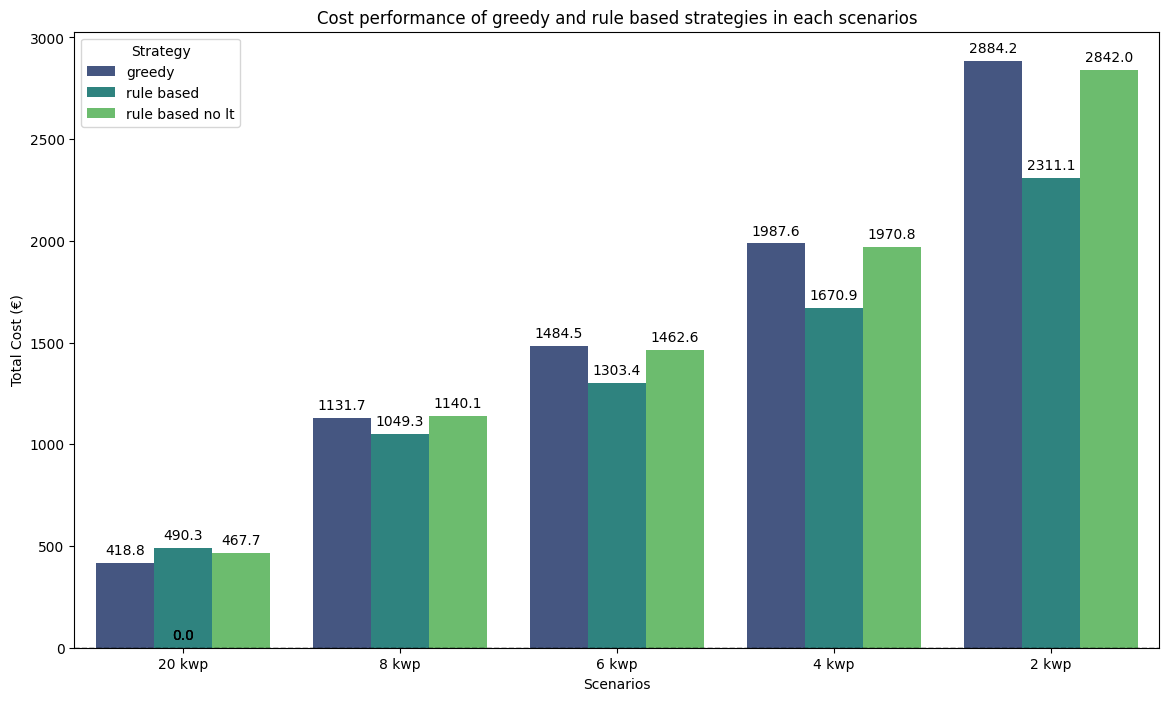

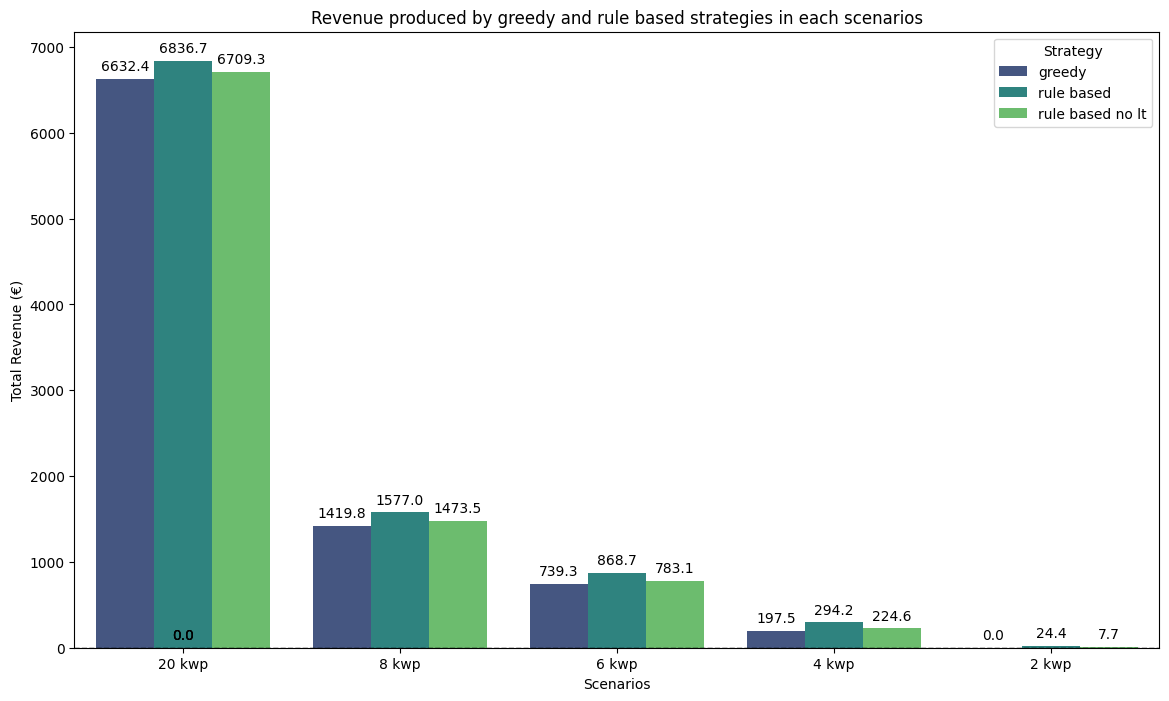

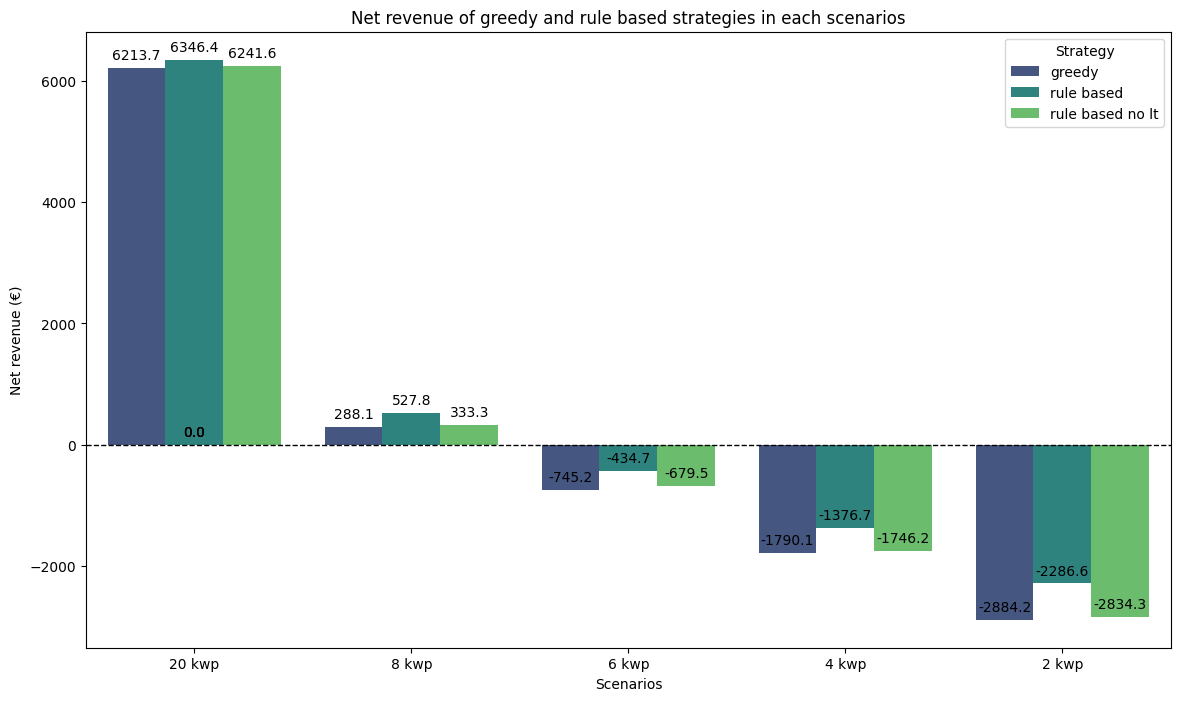

In [233]:
plt.figure(figsize=(14, 8))
ax = sns.barplot(x="scenario", y="total cost", hue="strategy", data=bardf, palette="viridis")

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'),
        (p.get_x() + p.get_width()/ 2., p.get_height()),
        ha = "center", va = "center",
        xytext = (0,9),
        textcoords = "offset points")

plt.xlabel("Scenarios")
plt.ylabel("Total Cost (€)")
plt.axhline(y=0,color="black",linestyle="--", linewidth=1, xmin=0, xmax=1)
plt.title("Cost performance of greedy and rule based strategies in each scenarios")
plt.legend(title="Strategy")
plt.savefig("../output/seaborn/greedy_vs_rule_total_cost.pdf", format='pdf')
#plt.show()

plt.figure(figsize=(14, 8))
ax = sns.barplot(x="scenario", y="total revenue", hue="strategy", data=bardf, palette="viridis")

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'),
        (p.get_x() + p.get_width()/ 2., p.get_height()),
        ha = "center", va = "center",
        xytext = (0,9),
        textcoords = "offset points")

plt.xlabel("Scenarios")
plt.ylabel("Total Revenue (€)")
plt.axhline(y=0,color="black",linestyle="--", linewidth=1, xmin=0, xmax=1)
plt.title("Revenue produced by greedy and rule based strategies in each scenarios")
plt.legend(title="Strategy")
plt.savefig("../output/seaborn/greedy_vs_rule_total_revenue.pdf", format='pdf')
plt.show()

plt.figure(figsize=(14, 8))
ax = sns.barplot(x="scenario", y="net revenue", hue="strategy", data=bardf, palette="viridis")

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'),
        (p.get_x() + p.get_width()/ 2., p.get_height()),
        ha = "center", va = "center",
        xytext = (0,9),
        textcoords = "offset points")

plt.xlabel("Scenarios")
plt.ylabel("Net revenue (€)")
plt.axhline(y=0,color="black",linestyle="--", linewidth=1, xmin=0, xmax=1)
plt.title("Net revenue of greedy and rule based strategies in each scenarios")
plt.legend(title="Strategy")
plt.savefig("../output/seaborn/greedy_vs_rule_net_revenue.pdf", format='pdf')
#plt.show()

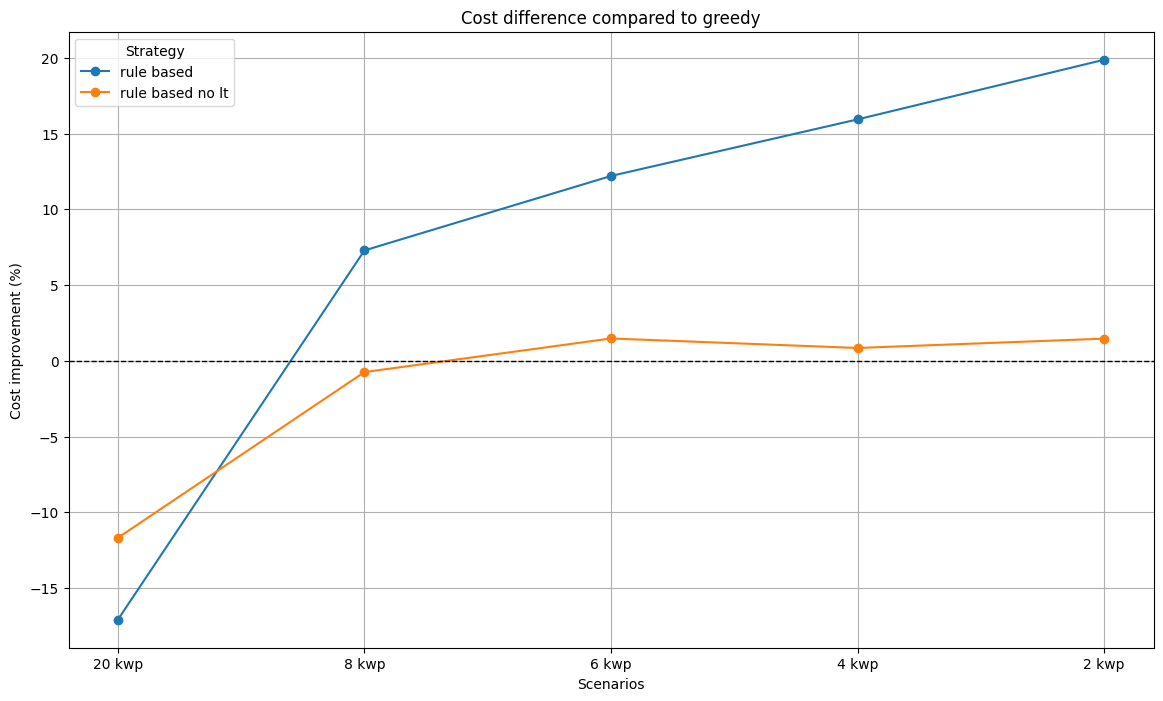

In [229]:
greedy_costs = bardf[bardf["strategy"] == "greedy"].set_index("scenario")["total cost"]
bardf["cost_diff"] = bardf.apply(lambda row: (row["total cost"] - greedy_costs[row["scenario"]])/greedy_costs[row["scenario"]]*(-100), axis=1)

plt.figure(figsize=(14, 8))

for strategy in ["rule based", "rule based no lt"]:
    subset = bardf[bardf["strategy"] == strategy]
    plt.plot(subset["scenario"], subset["cost_diff"], marker="o",label=strategy)

plt.xlabel("Scenarios")
plt.ylabel("Cost improvement (%)")
plt.axhline(y=0,color="black",linestyle="--", linewidth=1, xmin=0, xmax=1)
plt.title("Cost difference compared to greedy")
plt.legend(title="Strategy")
plt.grid(True)
plt.savefig("../output/seaborn/greedy_vs_rule_percent.pdf", format='pdf')

# Overall comparisons

In [220]:
df_extra = pandas.DataFrame(columns=["total cost","total revenue","net revenue","self-sufficiency rate","self-consumption rate","total export","total import","strategy"])

In [221]:
import pandas
data = {
    "total cost": [total_cost, simple_total_cost, rule_total_cost, rule_no_lt_total_cost, lp_total_cost, lp_rev_total_cost, lp_weeks_total_cost],
    "total revenue": [total_revenue, simple_total_revenue, rule_total_revenue, rule_no_lt_total_revenue, lp_total_revenue, lp_rev_total_revenue, lp_weeks_total_revenue],
    "net revenue": [net_revenue, simple_net_revenue, rule_net_revenue, rule_no_lt_net_revenue, lp_net_revenue, lp_rev_net_revenue, lp_weeks_net_revenue],
    "self-sufficiency rate": [pv_self_sufficiency_rate, simple_self_sufficiency_rate, rule_self_sufficiency_rate, rule_no_lt_self_sufficiency_rate, lp_self_sufficiency_rate, lp_rev_self_sufficiency_rate, lp_weeks_self_sufficiency_rate],
    "self-consumption rate": [pv_self_consumption_rate, simple_self_consumption_rate, rule_self_consumption_rate, rule_no_lt_self_consumption_rate, lp_self_consumption_rate, lp_rev_self_consumption_rate, lp_weeks_self_consumption_rate],
    "total export": [pv_total_export, simple_total_export, rule_total_export, rule_no_lt_total_export, lp_total_export, lp_rev_total_export, lp_weeks_total_export],
    "total import": [pv_total_import, simple_total_import, rule_total_import, rule_no_lt_total_import, lp_total_import, lp_rev_total_import, lp_weeks_total_import],
    "strategy": ["PV only","greedy", "rule based", "rule based no lt","lp","lp net revenue","lp weekly"],
}
df_extra = pandas.concat([df_extra,pandas.DataFrame(data)])
df_extra.head(100)

/tmp/ipykernel_3735/3353767653.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_extra = pandas.concat([df_extra,pandas.DataFrame(data)])


,total cost,total revenue,net revenue,self-sufficiency rate,self-consumption rate,total export,total import,strategy
0,3129.751953,190.838913,-2938.913086,0.210769,0.801182,1046.035034,15784.040039,PV only
1,2884.150032,0.000000,-2884.150032,0.263073,1.000000,0.000000,14738.004581,greedy
2,2311.059838,24.427029,-2286.632809,0.541459,0.937966,326.379834,15064.384415,rule based
3,2841.994730,7.682970,-2834.311760,0.262308,0.997094,15.290373,14753.294955,rule based no lt
4,1894.265272,23.085823,-1871.179449,0.893145,0.912587,4147.377753,18885.382330,lp
5,22247.107424,27336.110405,5089.002981,3.263003,0.841363,116363.351415,131101.355992,lp net revenue
6,1648.420522,-31.503161,-1679.923683,0.950328,0.955080,3819.309493,18557.314078,lp weekly


In [222]:
df_extra.to_csv(f"../output/seaborn/total_comparison_{scale_factor}_kwp.csv")

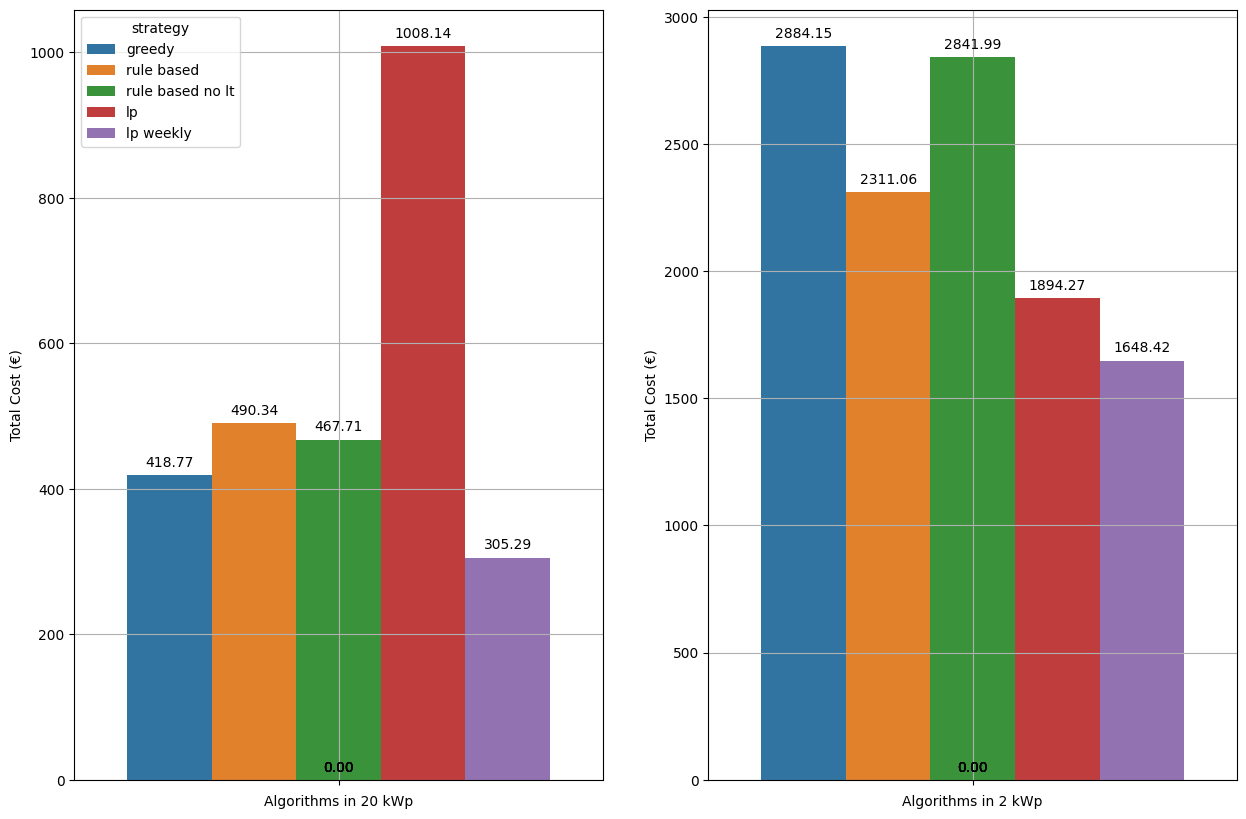

In [20]:
overall_20 = pandas.read_csv(f"../output/seaborn/total_comparison_20_kwp.csv")
overall_2 = pandas.read_csv(f"../output/seaborn/total_comparison_2_kwp.csv")
overall_20 = overall_20[(overall_20["strategy"] != "PV only") &
                        (overall_20["strategy"] != "lp net revenue")]
overall_2 = overall_2[(overall_2["strategy"] != "PV only") &
                        (overall_2["strategy"] != "lp net revenue")]

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
barplot_20 = sns.barplot(data=overall_20, y="total cost", hue="strategy", ax=axes[0])
axes[0].set_xlabel("Algorithms in 20 kWp")
axes[0].set_ylabel("Total Cost (€)")
axes[0].grid(True)

barplot_2 = sns.barplot(data=overall_2, y="total cost", hue="strategy", ax=axes[1])
axes[1].set_xlabel("Algorithms in 2 kWp")
axes[1].set_ylabel("Total Cost (€)")
axes[1].grid(True)

for p in barplot_20.patches:
    barplot_20.annotate(format(p.get_height(), '.2f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center', 
                     xytext = (0, 9),
                     textcoords = 'offset points')

for p in barplot_2.patches:
    barplot_2.annotate(format(p.get_height(), '.2f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points')
barplot_2.get_legend().remove()

plt.savefig(f"../output/seaborn/overall_cost_20_and_2_pkw.pdf", format='pdf')

/tmp/ipykernel_3671/1004074731.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
/tmp/ipykernel_3671/1004074731.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)


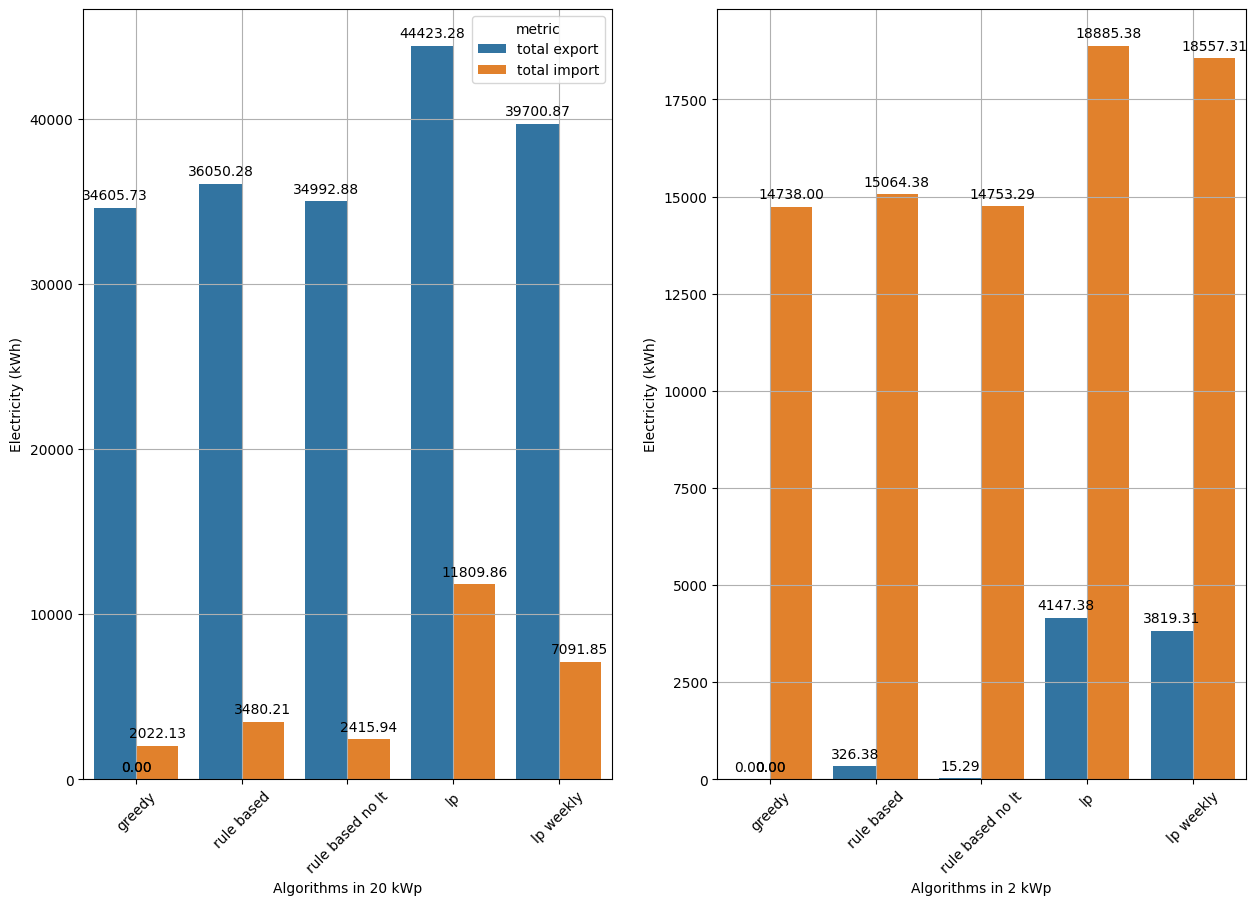

In [24]:
overall_20 = pandas.read_csv(f"../output/seaborn/total_comparison_20_kwp.csv")
overall_2 = pandas.read_csv(f"../output/seaborn/total_comparison_2_kwp.csv")
overall_20 = overall_20[(overall_20["strategy"] != "PV only") &
                        (overall_20["strategy"] != "lp net revenue")]
overall_2 = overall_2[(overall_2["strategy"] != "PV only") &
                        (overall_2["strategy"] != "lp net revenue")]

overall_20 = overall_20.melt(id_vars="strategy", value_vars =["total export","total import"], var_name="metric", value_name="value")
overall_2 = overall_2.melt(id_vars="strategy", value_vars =["total export","total import"], var_name="metric", value_name="value")

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
barplot_20 = sns.barplot(data=overall_20, x='strategy', y='value', hue='metric', ax=axes[0])
axes[0].set_xlabel("Algorithms in 20 kWp")
axes[0].set_ylabel("Electricity (kWh)")
axes[0].grid(True)

barplot_2 = sns.barplot(data=overall_2, x='strategy', y='value', hue='metric', ax=axes[1])
axes[1].set_xlabel("Algorithms in 2 kWp")
axes[1].set_ylabel("Electricity (kWh)")
axes[1].grid(True)

for p in barplot_20.patches:
    barplot_20.annotate(format(p.get_height(), '.2f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center', 
                     xytext = (0, 9),
                     textcoords = 'offset points')

for p in barplot_2.patches:
    barplot_2.annotate(format(p.get_height(), '.2f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points')

barplot_2.get_legend().remove()

axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.savefig(f"../output/seaborn/overall_import_export_20_and_2_pkw.pdf", format='pdf')

In [242]:
option = 8

In [243]:
overall_df = pandas.read_csv(f"../output/seaborn/total_comparison_{option}_kwp.csv")
overall_df.head(100)

,Unnamed: 0,total cost,total revenue,net revenue,self-sufficiency rate,self-consumption rate,total export,total import,strategy
0,0,2423.786133,2472.420654,48.634651,0.395269,0.375627,13139.989258,12094.181641,PV only
1,1,1131.682770,1419.812715,288.129945,0.707197,0.672054,6901.652804,5855.847013,greedy
2,2,1049.258465,1577.034125,527.775660,0.799849,0.608253,8244.338228,7198.532437,rule based
3,3,1140.124741,1473.451424,333.326683,0.694480,0.659969,7155.977124,6110.171333,rule based no lt
4,4,1267.777299,2064.390671,796.613372,0.912015,0.463606,15009.324374,13963.518588,lp
5,5,21339.367302,29415.917847,8076.550546,2.945989,0.505794,127110.744387,126064.938607,lp net revenue
6,6,680.025258,1408.229243,728.203985,0.974276,0.614839,11820.382020,10774.576239,lp weekly


In [244]:
filtered_df = overall_df[overall_df["strategy"] != "lp net revenue"]

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

filtered_melt = filtered_df.melt(id_vars="strategy", value_vars =["total cost","total revenue", "net revenue",
                                                                  "self-sufficiency rate", "self-consumption rate",
                                                                  "total export","total import"],
                                 var_name="metric", value_name="value")


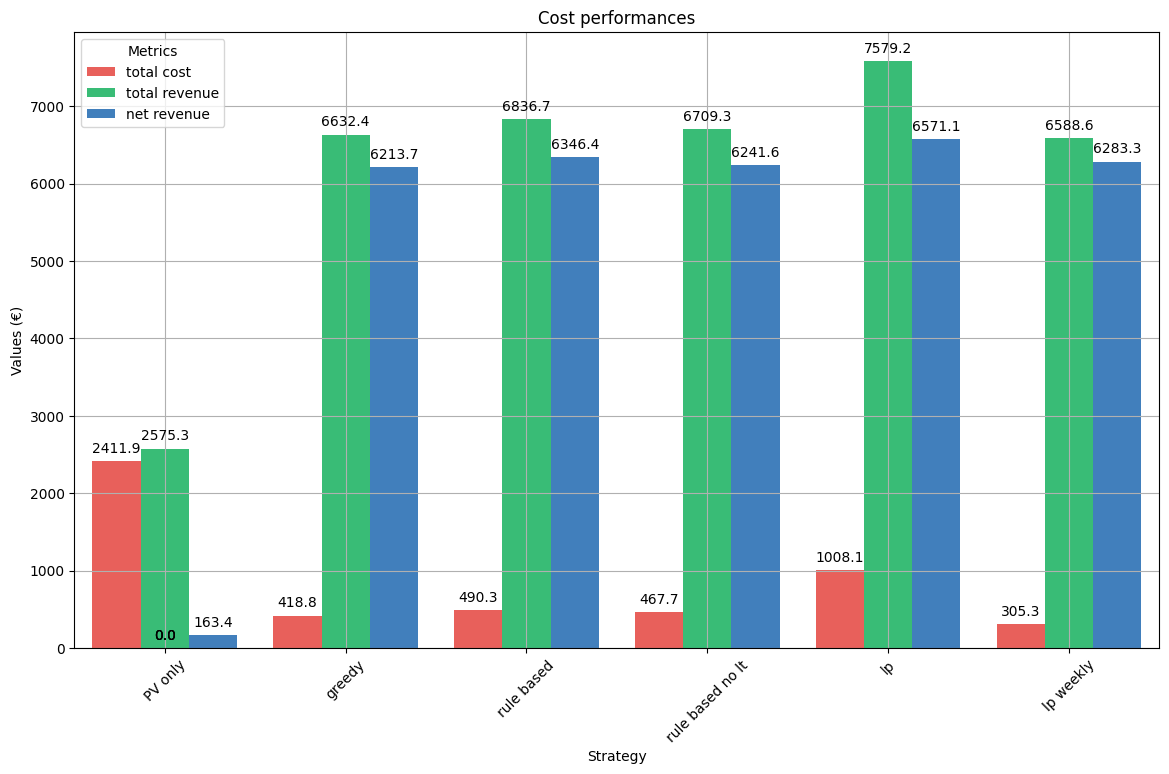

In [126]:
cost_metrics = ['total cost', 'total revenue', 'net revenue']
cost_melt = filtered_melt[filtered_melt['metric'].isin(cost_metrics)]
cost_palette = ["#FF4A44", "#23D274","#2D7FD0"]

overall_melt = overall_df.melt(id_vars="strategy", value_vars =["total cost","total revenue", "net revenue"],
                                 var_name="metric", value_name="value")
plt.figure(figsize=(14, 8))
ax = sns.barplot(x='strategy', y='value', hue='metric', data=cost_melt, palette=cost_palette)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'),
        (p.get_x() + p.get_width()/ 2., p.get_height()),
        ha = "center", va = "center",
        xytext = (0,9),
        textcoords = "offset points")

plt.xlabel("Strategy")
plt.ylabel("Values (€)")
plt.title("Cost performances")
plt.legend(title="Metrics")
plt.xticks(rotation=45)
plt.grid(True)
plt.savefig(f"../output/seaborn/overall_cost_{option}_pkw.pdf", format='pdf')
plt.show()


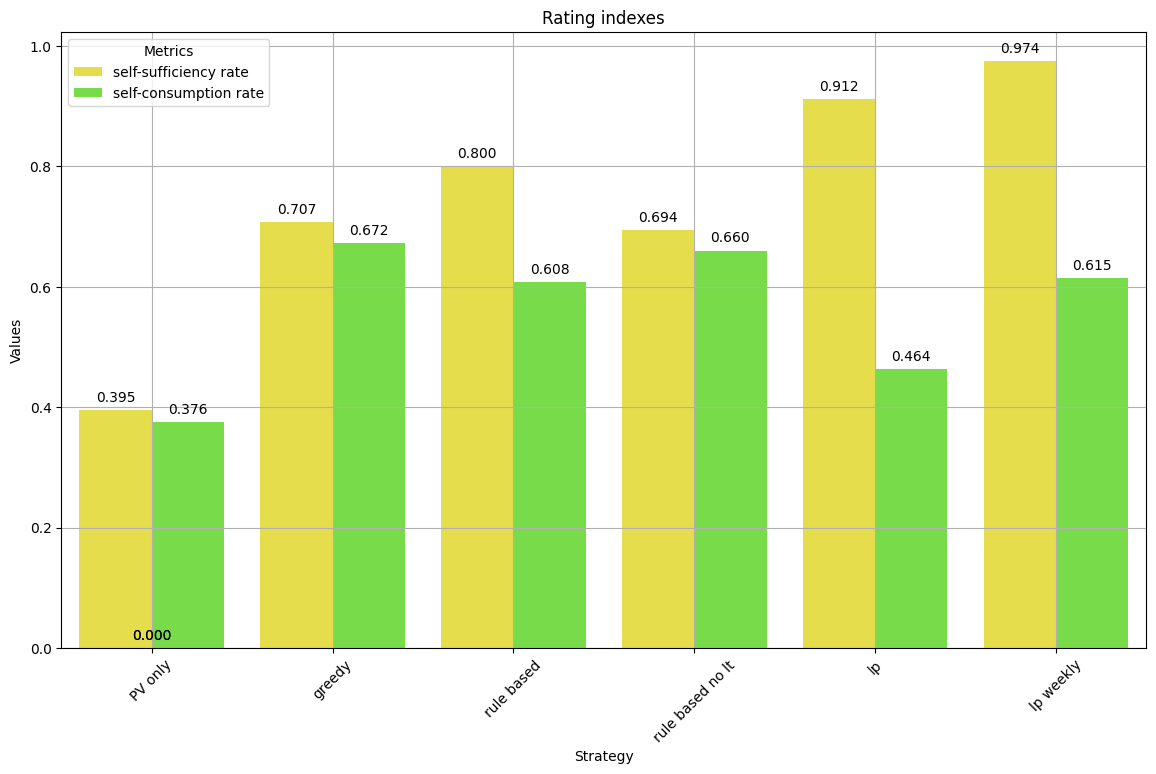

In [109]:
rating_metrics = ["self-sufficiency rate", "self-consumption rate"]
rating_melt = filtered_melt[filtered_melt['metric'].isin(rating_metrics)]
rating_palette = ["#FFF432","#6FF432"]

plt.figure(figsize=(14, 8))
ax = sns.barplot(x='strategy', y='value', hue='metric', data=rating_melt, palette=rating_palette)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'),
        (p.get_x() + p.get_width()/ 2., p.get_height()),
        ha = "center", va = "center",
        xytext = (0,9),
        textcoords = "offset points")

plt.xlabel("Strategy")
plt.ylabel("Values")
plt.title("Rating indexes")
plt.legend(title="Metrics")
plt.xticks(rotation=45)
plt.grid(True)
plt.savefig(f"../output/seaborn/overall_ratings_{option}_pkw.pdf", format='pdf')
plt.show()

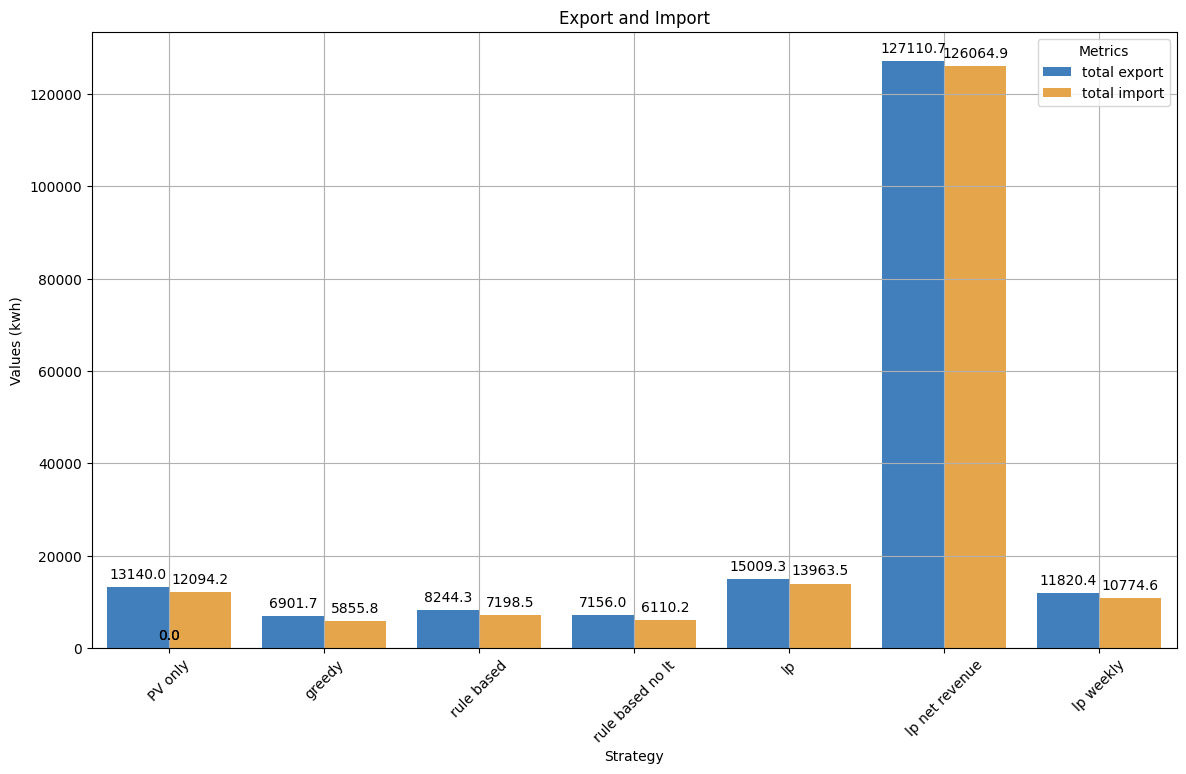

In [246]:

export_import_metrics = ["total export", "total import"]
export_import_melt = filtered_melt[filtered_melt['metric'].isin(export_import_metrics)]
export_import_palette = ["#2D7FD0","#FFAB31"]

overall_melt = overall_df.melt(id_vars="strategy", value_vars =["total export","total import"],
                                 var_name="metric", value_name="value")

plt.figure(figsize=(14, 8))
ax = sns.barplot(x='strategy', y='value', hue='metric', data=overall_melt, palette=export_import_palette)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'),
        (p.get_x() + p.get_width()/ 2., p.get_height()),
        ha = "center", va = "center",
        xytext = (0,9),
        textcoords = "offset points")

plt.xlabel("Strategy")
plt.ylabel("Values (kwh)")
plt.title("Export and Import")
plt.legend(title="Metrics")
plt.xticks(rotation=45)
plt.grid(True)
plt.savefig(f"../output/seaborn/overall_export_import_with_net_rev_{option}_pkw.pdf", format='pdf')
plt.show()

**LP interval comparison**

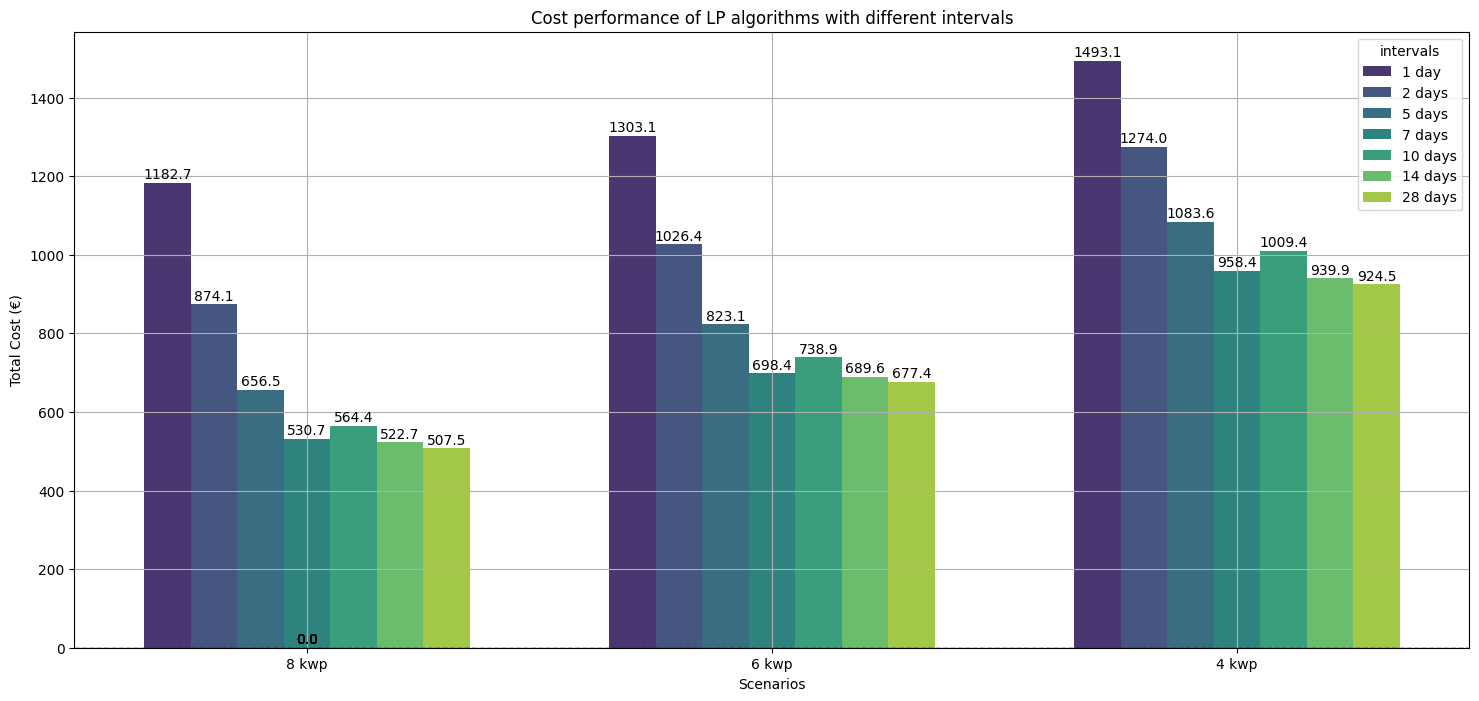

In [58]:
import pandas
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 8))

lp_df = pandas.read_csv("../output/seaborn/lp_intervals.csv")
ax = sns.barplot(x="scenario", y="total cost", hue="interval", data=lp_df, palette="viridis", width=0.7)
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'),
        (p.get_x() + p.get_width()/ 2., p.get_height()),
        ha = "center", va = "center",
        xytext= (0, 6),
        textcoords = "offset points")

plt.xlabel("Scenarios")
plt.ylabel("Total Cost (€)")
plt.axhline(y=0,color="black",linestyle="--", linewidth=1, xmin=0, xmax=1)
plt.title("Cost performance of LP algorithms with different intervals")
plt.legend(title="intervals")
plt.grid(True)
plt.savefig(f"../output/seaborn/lp_interval_comparision.png", format='png')
plt.show()

**Line diagrams**

In [129]:
lp_data = pandas.read_csv(f"../output/seaborn/lp_output_{option}.csv")
lp_data.head()

,timestamp,consumption_kwh,production_kwh,price_eur_per_mwh,date,soc,ch,dch,c_in,c_out,buy_price,sell_price,surplus,deficit
0,2022-01-01 01:00:00,0.18187,0.0,41.33,2022-01-01,0.00000,0.00000,0.00000,0.18187,0.0,0.007517,0.0,-0.18187,1.818700e-01
1,2022-01-01 01:15:00,0.18158,0.0,41.33,2022-01-01,0.00000,0.00000,0.00000,0.18158,0.0,0.007505,0.0,-0.18158,1.815800e-01
2,2022-01-01 01:30:00,0.18087,0.0,41.33,2022-01-01,0.00000,0.00000,0.00000,0.18087,0.0,0.007475,0.0,-0.18087,1.808700e-01
3,2022-01-01 01:45:00,0.18103,0.0,41.33,2022-01-01,1.43706,1.43706,0.00000,1.61809,0.0,0.066876,0.0,-1.61809,1.810300e-01
4,2022-01-01 02:00:00,0.18172,0.0,43.22,2022-01-01,1.25534,0.00000,0.18172,0.00000,0.0,0.000000,0.0,-0.18172,3.485680e-09


In [51]:
import pandas
option = 8

pv_data = pandas.read_csv(f"../output/seaborn/pv_output_{option}_kw.csv")
pv_data = pv_data[["timestamp","buy_price","net_revenue","c_in","c_out"]]
pv_data = pv_data.rename(columns={"buy_price":"cost"})
pv_data = pv_data.assign(soc= 0.0000,
                         strategy = "pv")

greedy_data = pandas.read_csv(f"../output/seaborn/greedy_output_{option}_kw.csv")
greedy_data = greedy_data.assign(net_revenue= lambda x: x["sell_price"] - x["buy_price"],
                                 strategy= "greedy")
greedy_data = greedy_data[["timestamp","buy_price","net_revenue", "SOC_end","c_in","c_out","strategy"]]
greedy_data = greedy_data.rename(columns={"buy_price":"cost", "SOC_end":"soc"})

rb_data = pandas.read_csv(f"rb_output_{option}_kw.csv")
rb_data = rb_data.assign(net_revenue= lambda x: x["sell_price"] - x["buy_price"],
                                 strategy= "rule based")
rb_data = rb_data[["timestamp","buy_price","net_revenue","SOC_end", "c_in","c_out","strategy"]]
rb_data = rb_data.rename(columns={"buy_price":"cost", "SOC_end":"soc"})

rb_no_lt_data = pandas.read_csv(f"rb_no_lt_output_{option}_kw.csv")
rb_no_lt_data = rb_no_lt_data.assign(net_revenue= lambda x: x["sell_price"] - x["buy_price"],
                                 strategy= "rule based no lt")
rb_no_lt_data = rb_no_lt_data[["timestamp","buy_price","net_revenue", "SOC_end","c_in","c_out","strategy"]]
rb_no_lt_data = rb_no_lt_data.rename(columns={"buy_price":"cost", "SOC_end":"soc"})

lp_data = pandas.read_csv(f"lp_output_{option}_kw.csv")
lp_data = lp_data.assign(net_revenue= lambda x: x["sell_price"] - x["buy_price"],
                                 strategy= "lp")
lp_data = lp_data[["timestamp","buy_price","net_revenue", "soc","c_in","c_out","strategy"]]
lp_data = lp_data.rename(columns={"buy_price":"cost"})

lp_weekly_data = pandas.read_csv(f"lp_weekly_output_{option}_kw.csv")
lp_weekly_data = lp_weekly_data.assign(net_revenue= lambda x: x["sell_price"] - x["buy_price"],
                                 strategy= "lp weekly")
lp_weekly_data = lp_weekly_data[["timestamp","buy_price","net_revenue", "soc","c_in","c_out","strategy"]]
lp_weekly_data = lp_weekly_data.rename(columns={"buy_price":"cost"})

lp_net_rev_data = pandas.read_csv(f"../output/seaborn/lp_rev_output_{option}.csv")
lp_net_rev_data = lp_net_rev_data.assign(net_revenue= lambda x: x["sell_price"] - x["buy_price"],
                                 strategy= "lp net revenue")
lp_net_rev_data = lp_net_rev_data[["timestamp","buy_price","net_revenue", "soc","c_in","c_out","strategy"]]
lp_net_rev_data = lp_net_rev_data.rename(columns={"buy_price":"cost"})


overall_data = pandas.concat([pv_data,greedy_data,rb_data,rb_no_lt_data,lp_data,lp_weekly_data,lp_net_rev_data],axis=0)
overall_data['cumulative cost'] = overall_data.groupby('strategy')['cost'].cumsum()
overall_data['cumulative net revenue'] = overall_data.groupby("strategy")['net_revenue'].cumsum()

overall_data.head()

,timestamp,cost,net_revenue,c_in,c_out,soc,strategy,cumulative cost,cumulative net revenue
0,2022-01-01 01:00:00,0.007517,-0.007517,0.18187,0.0,0.0,pv,0.007517,-0.007517
1,2022-01-01 01:15:00,0.007505,-0.007505,0.18158,0.0,0.0,pv,0.015021,-0.015021
2,2022-01-01 01:30:00,0.007475,-0.007475,0.18087,0.0,0.0,pv,0.022497,-0.022497
3,2022-01-01 01:45:00,0.007482,-0.007482,0.18103,0.0,0.0,pv,0.029979,-0.029979
4,2022-01-01 02:00:00,0.007854,-0.007854,0.18172,0.0,0.0,pv,0.037833,-0.037833


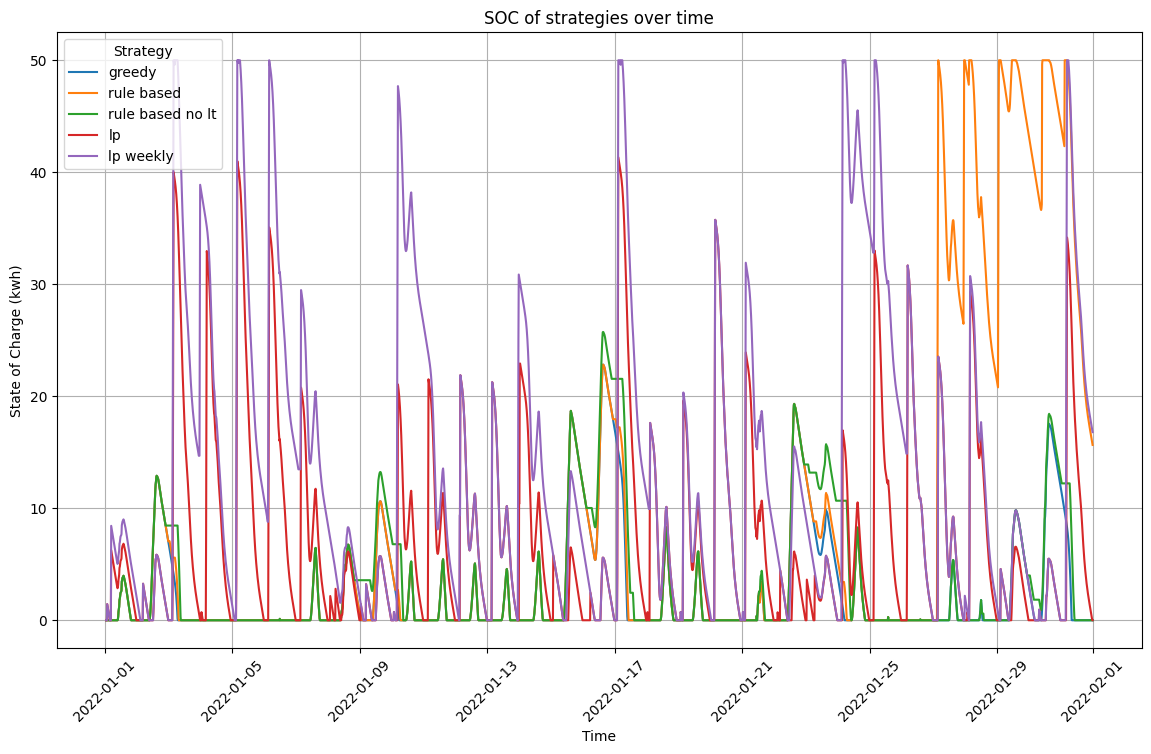

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

overall_data['timestamp'] = pd.to_datetime(overall_data['timestamp'])

overall_data_1 = overall_data[(overall_data["timestamp"] <= "2022-02-01") & 
                            (overall_data["timestamp"] >= "2021-12-30") &
                            (overall_data["strategy"] != "lp net revenue") &
                            (overall_data["strategy"] != "pv")]

#overall_data = overall_data[(overall_data["timestamp"] <= "2022-08-01") & 
#                            (overall_data["timestamp"] >= "2022-06-01") & 
#                            (overall_data["strategy"] != "pv") &
#                            (overall_data["strategy"] != "lp net revenue")]

plt.figure(figsize=(14, 8))
sns.lineplot(data=overall_data_1, x='timestamp', y='soc', hue='strategy', palette='tab10')


plt.title(f"SOC of strategies over time")
plt.xlabel("Time")
plt.ylabel("State of Charge (kwh)")
plt.xticks(rotation=45)
plt.legend(title="Strategy")
plt.grid(True)

plt.savefig(f"../output/seaborn/soc_values_over_time_jan_{option}_pkw.pdf", format='pdf', bbox_inches='tight')
plt.show()

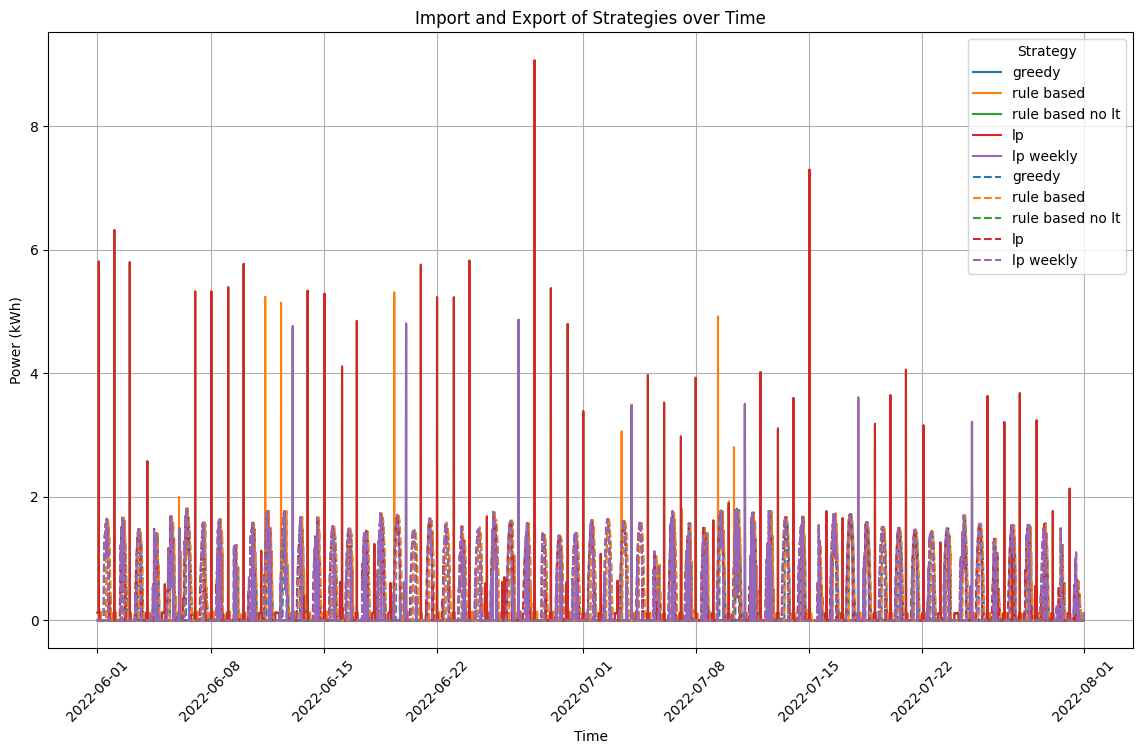

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

overall_data['timestamp'] = pd.to_datetime(overall_data['timestamp'])

#overall_data_im_ex = overall_data[(overall_data["timestamp"] <= "2022-02-01") & 
#                                  (overall_data["timestamp"] >= "2021-12-30") & 
#                                  (overall_data["strategy"] != "lp net revenue") & 
#                                  (overall_data["strategy"] != "pv")]

overall_data_im_ex = overall_data[(overall_data["timestamp"] <= "2022-08-01") & 
                            (overall_data["timestamp"] >= "2022-06-01") & 
                            (overall_data["strategy"] != "pv") &
                            (overall_data["strategy"] != "lp net revenue")]

plt.figure(figsize=(14, 8))


sns.lineplot(data=overall_data_im_ex, x='timestamp', y='c_in', hue='strategy', palette='tab10', linestyle='-')

sns.lineplot(data=overall_data_im_ex, x='timestamp', y='c_out', hue='strategy', palette='tab10', linestyle='--')

plt.title(f"Import and Export of Strategies over Time")
plt.xlabel("Time")
plt.ylabel("Power (kWh)")
plt.xticks(rotation=45)
plt.legend(title="Strategy")
plt.grid(True)

plt.savefig(f"../output/seaborn/im_ex_values_over_time_july_{option}_pkw.pdf", format='pdf', bbox_inches='tight')
plt.show()


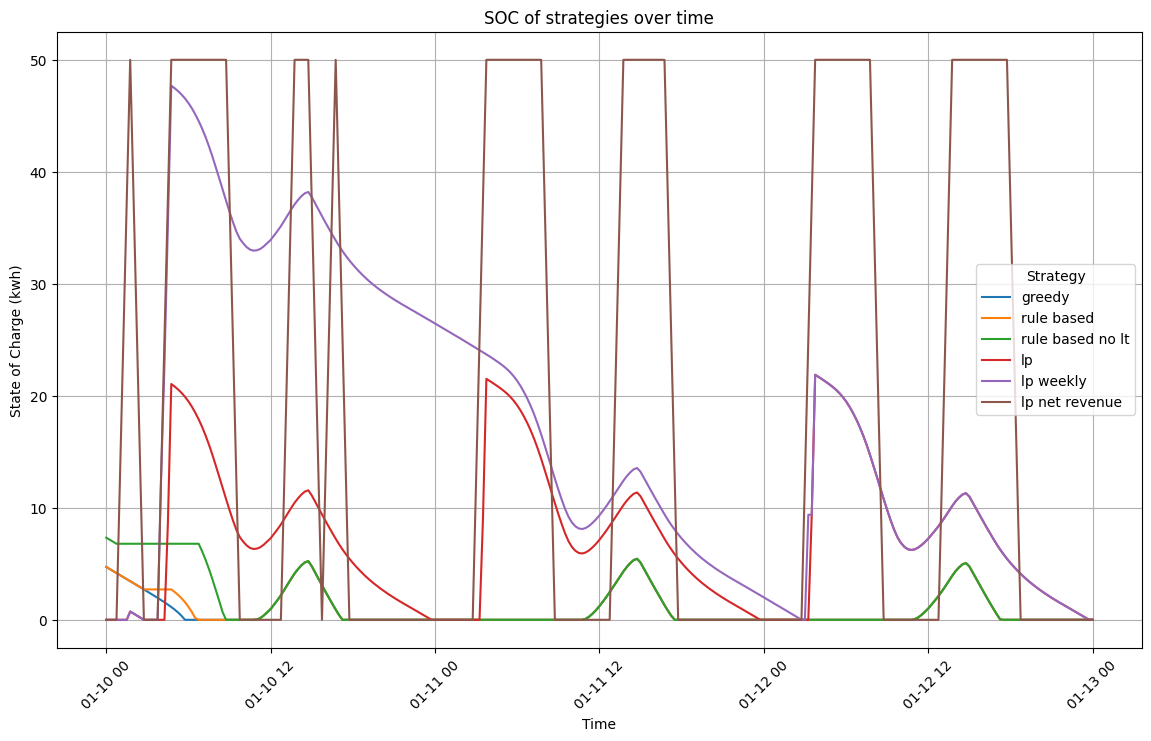

In [241]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

overall_data['timestamp'] = pd.to_datetime(overall_data['timestamp'])



overall_data_1 = overall_data[(overall_data["timestamp"] <= "2022-01-13") & 
                            (overall_data["timestamp"] >= "2022-01-10") & 
                            (overall_data["strategy"] != "pv")]
                            #(overall_data["strategy"] != "lp net revenue")]

plt.figure(figsize=(14, 8))
sns.lineplot(data=overall_data_1, x='timestamp', y='soc', hue='strategy', palette='tab10')


plt.title(f"SOC of strategies over time")
plt.xlabel("Time")
plt.ylabel("State of Charge (kwh)")
plt.xticks(rotation=45)
plt.legend(title="Strategy")
plt.grid(True)

plt.savefig(f"../output/seaborn/soc_values_over_time_jan_with_net_rev_{option}_pkw.pdf", format='pdf', bbox_inches='tight')
plt.show()

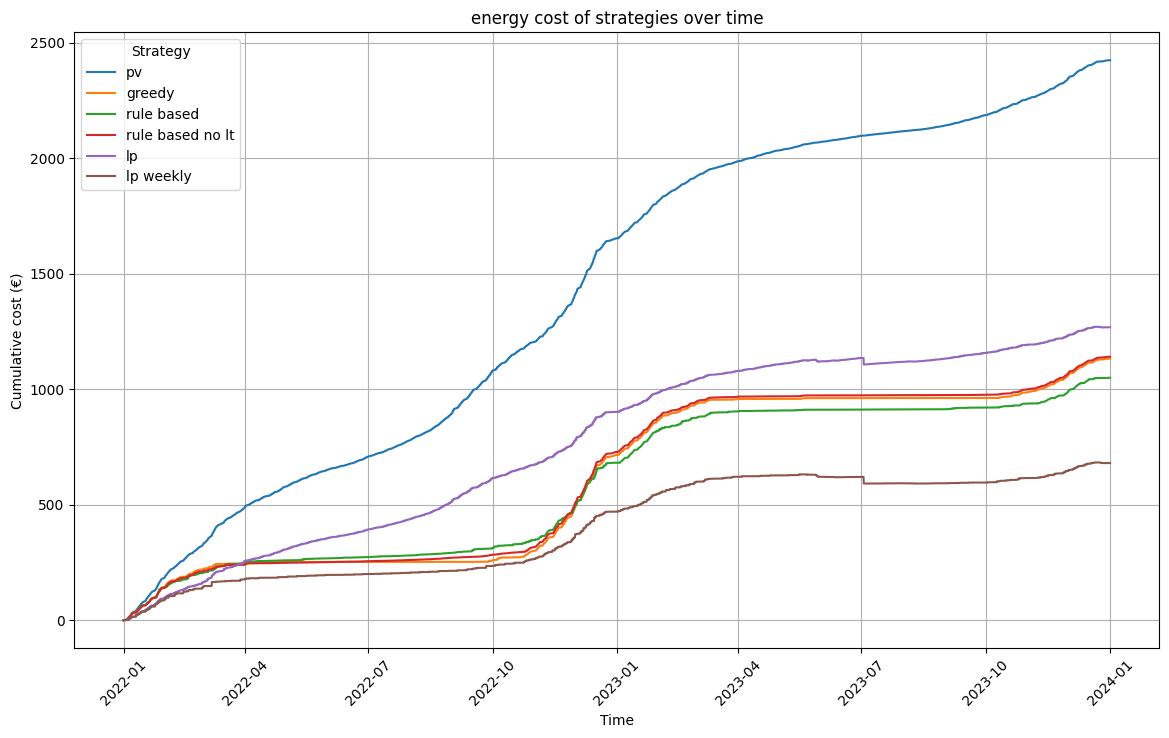

In [3]:
overall_data['timestamp'] = pd.to_datetime(overall_data['timestamp'])

#overall_data = overall_data[(overall_data["timestamp"] <= "2022-02-01") & 
#                            (overall_data["strategy"] != "lp net revenue") &
#                            (overall_data["strategy"] != "pv")]

#overall_data = overall_data[(overall_data["timestamp"] <= "2022-08-01") & 
#                            (overall_data["timestamp"] >= "2022-06-01") & 
#                            (overall_data["strategy"] != "pv") &
#                            (overall_data["strategy"] != "lp net revenue")]
overall_data = overall_data[overall_data["strategy"] != "lp net revenue"]

plt.figure(figsize=(14, 8))
sns.lineplot(data=overall_data, x='timestamp', y='cumulative cost', hue='strategy', palette='tab10')


plt.title(f"energy cost of strategies over time")
plt.xlabel("Time")
plt.ylabel("Cumulative cost (€)")
plt.xticks(rotation=45)
plt.legend(title="Strategy")
plt.grid(True)

plt.savefig(f"../output/seaborn/cumulative_cost_over_time_{option}_pkw.pdf", format='pdf', bbox_inches='tight')
plt.show()

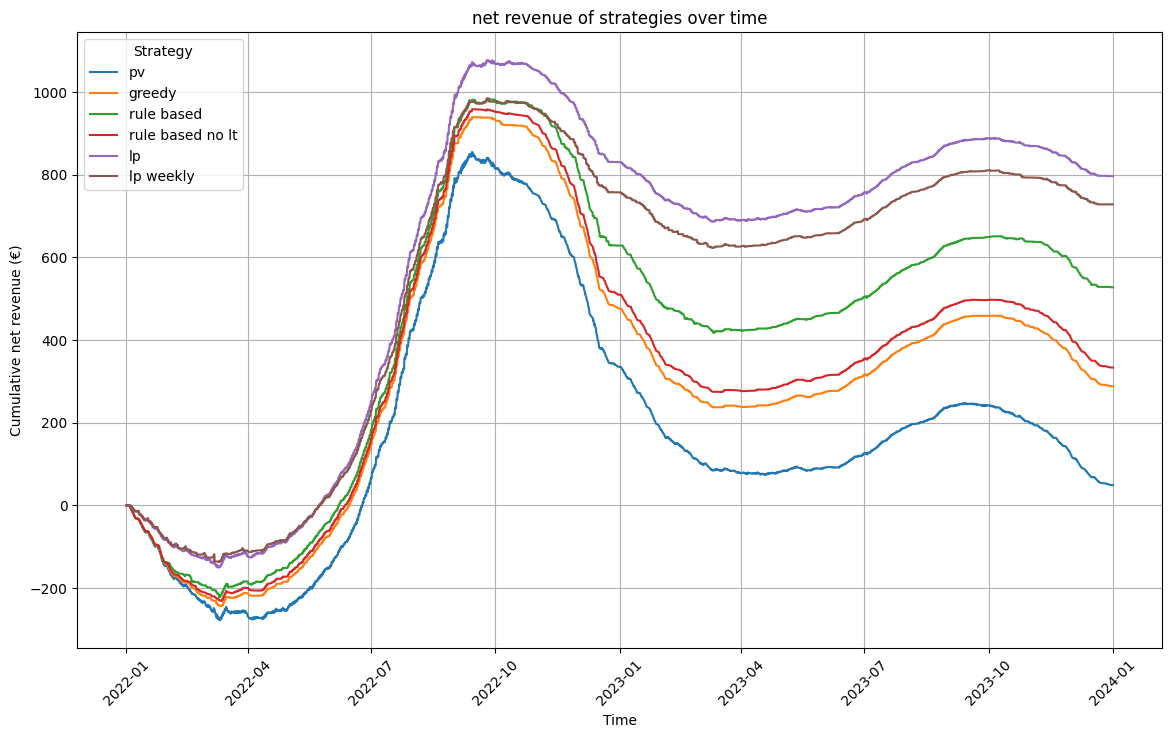

In [215]:
overall_data['timestamp'] = pd.to_datetime(overall_data['timestamp'])

#overall_data = overall_data[(overall_data["timestamp"] <= "2022-02-01") & 
#                            (overall_data["strategy"] != "lp net revenue") &
#                            (overall_data["strategy"] != "pv")]

#overall_data = overall_data[(overall_data["timestamp"] <= "2022-08-01") & 
#                            (overall_data["timestamp"] >= "2022-06-01") & 
#                            (overall_data["strategy"] != "pv") &
#                            (overall_data["strategy"] != "lp net revenue")]
overall_data = overall_data[overall_data["strategy"] != "lp net revenue"]


plt.figure(figsize=(14, 8))
sns.lineplot(data=overall_data, x='timestamp', y='cumulative net revenue', hue='strategy', palette='tab10')


plt.title(f"net revenue of strategies over time")
plt.xlabel("Time")
plt.ylabel("Cumulative net revenue (€)")
plt.xticks(rotation=45)
plt.legend(title="Strategy")
plt.grid(True)

plt.savefig(f"../output/seaborn/cumulative_net_revenue_over_time_lp_net_rev_{option}_pkw.pdf", format='pdf', bbox_inches='tight')
plt.show()

# Testing area

In [72]:
import pandas
header = ["production_kwh", "consumption_kwh","price_eur_per_mwh"]
data = [
        (100,110,10),
        (90,120,12),
        (95,90,9),
        (105,65,5),
        (50,80,12),
        (100,100,20),
        (100,100,20),
        (250,100,20),
        (10,100,20),
        (200,100,20)
        ]
tester = pandas.DataFrame(data, columns=header)


asd = tester["production_kwh"].quantile(0.2, interpolation="linear")

print(asd)

82.0


In [78]:
df = spark.read.format("csv")\
          .option("header","true")\
          .option("delimiter",";")\
          .load("../output/percentiles_177k_10000_kwh_per_y/177k.csv")

In [80]:
df.orderBy(col("total_cost")).show()

+---------------+---------------------+---------------------+------------------+-----------------+------------------+
|    percentiles|self_consumption_rate|self_sufficiency_rate|        total_cost|    total_revenue|       net_revenue|
+---------------+---------------------+---------------------+------------------+-----------------+------------------+
|0.5,0.1,0.1,0.3|   0.7771400053112751|   0.5927319262843158|10.237793469841245|2.442111867787913|-7.795681602053332|
|0.5,0.1,0.2,0.3|   0.7771400053112751|   0.5927319262843158|10.237793469841245|2.442111867787913|-7.795681602053332|
|0.4,0.1,0.1,0.3|   0.7771400053112751|   0.5927319262843158|10.240387689720324|2.442111867787913| -7.79827582193241|
|0.4,0.1,0.2,0.3|   0.7771400053112751|   0.5927319262843158|10.240387689720324|2.442111867787913| -7.79827582193241|
|0.3,0.1,0.1,0.3|   0.7771400053112751|   0.5927319262843158|10.245589135794862|2.442111867787913|-7.803477268006949|
|0.3,0.1,0.2,0.3|   0.7771400053112751|   0.592731926284

In [66]:
df = spark.read.format("csv").option("header","true").option("delimiter",";").load("../output/percentiles_6.csv/percentiles_6.csv")

In [67]:
df.orderBy("total_cost").show()

+---------------+---------------------+---------------------+------------------+------------------+-------------------+
|    percentiles|self_consumption_rate|self_sufficiency_rate|        total_cost|     total_revenue|        net_revenue|
+---------------+---------------------+---------------------+------------------+------------------+-------------------+
|0.7,0.2,0.1,0.6|   0.7982316127143183|   0.5405131382415056|12.454943507872265| 1.900574032713624| -10.55436947515864|
|0.7,0.2,0.2,0.6|   0.7982316127143183|   0.5405131382415056|12.454943507872265| 1.900574032713624| -10.55436947515864|
|0.4,0.2,0.1,0.6|   0.7982316127143183|   0.5405131382415056|12.459138141190799| 1.900574032713624|-10.558564108477174|
|0.4,0.2,0.2,0.6|   0.7982316127143183|   0.5405131382415056|12.459138141190799| 1.900574032713624|-10.558564108477174|
|0.7,0.1,0.2,0.6|   0.7982316127143183|   0.5405131382415056|12.459472889339274| 1.900574032713624| -10.55889885662565|
|0.7,0.1,0.1,0.6|   0.7982316127143183| 